In [1]:
!pip install faster-whisper==1.1.1 "nemo_toolkit[asr]" "mistral-common[audio]" spacy sentencepiece tabpfn-client
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 903.9/903.9 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65

In [2]:
%%writefile extract_features.py
"""Feature extraction for the SHL grammar-scoring notebook.

Writes every feature the notebook uses into features/. The GPU steps need two GPUs (we used Kaggle, 2x T4,
internet on, competition data attached, about 8 GPU-hours in total). Install the extra packages first:

    pip install faster-whisper==1.1.1 "nemo_toolkit[asr]" "bitsandbytes>=0.46.1" "mistral-common[audio]" spacy
    python -m spacy download en_core_web_sm
    python extract_features.py                         # all steps
    python extract_features.py --steps text_llm gec    # some steps (they can run in separate sessions)

Steps, in dependency order: waveform, asr, encoders, decoder, audio_llm, text_llm, gec, hand.
decoder, text_llm, gec and hand read the ASR outputs; hand also reads the waveform and gec outputs.
"""
import argparse
import difflib
import glob
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
from joblib import Parallel, delayed

# set in main(); the forked GPU jobs inherit them
DATA = FEAT = KEYS = CLIPS = None
N_CLIPS = None


def reorder(keys):
    pos = {k: i for i, k in enumerate(keys)}
    return np.array([pos[k] for k in KEYS])


def load_audio(path):
    x, sr = sf.read(path, dtype='float32')
    return (x.mean(1) if x.ndim > 1 else x), sr


def run_on_gpus(*jobs):
    """Run each GPU job in its own forked process, in parallel (one per GPU). Models load independently and
    all GPU memory is released when a job ends. The main process itself never initialises CUDA."""
    import multiprocessing as mp
    procs = [mp.get_context('fork').Process(target=fn, args=args) for fn, *args in jobs]
    for p in procs:
        p.start()
    for p in procs:
        p.join()
    failed = [jobs[i][0].__name__ for i, p in enumerate(procs) if p.exitcode != 0]
    if failed:
        raise RuntimeError(f'failed: {failed}')


# waveform statistics, gate statistic and prosody

def audio_stats():
    rows = []
    for key, path in CLIPS:
        x, sr = load_audio(path)
        frames = x[: len(x) // 400 * 400].reshape(-1, 400)
        db = 20 * np.log10(np.sqrt((frames ** 2).mean(1) + 1e-12) + 1e-9)
        split, filename = key.split('/')
        rows.append(dict(split=split, filename=filename, sr=sr, duration=len(x) / sr, rms=float(np.sqrt((x ** 2).mean())),
                         peak=float(np.abs(x).max()), db_max=float(db.max()), db_p50=float(np.median(db)),
                         db_p90=float(np.percentile(db, 90)), voiced_frac=float((db > max(db.max() - 35, -60)).mean()),
                         frac_zero=float((x == 0).mean()), dc=float(x.mean())))
    pd.DataFrame(rows).to_csv(FEAT / 'asr/audio_stats.csv', index=False)


def speech_ratio(path):
    x, _ = load_audio(path)
    frames = x[: len(x) // 400 * 400].reshape(-1, 400)
    return float((np.sqrt((frames ** 2).mean(1)) > 0.02).mean())


def run_lengths(mask):
    d = np.diff(np.concatenate([[0], mask.astype(np.int8), [0]]))
    return np.where(d == -1)[0] - np.where(d == 1)[0]


def prosody(path):
    import librosa
    x, sr = load_audio(path)
    db = 20 * np.log10(librosa.feature.rms(y=x, frame_length=400, hop_length=160)[0] + 1e-6)     # 10 ms hop
    active = db > np.percentile(db, 95) - 35
    f = {'pr_active_ratio': float(active.mean()), 'pr_peak': float(np.abs(x).max()),
         'pr_rms_db': float(20 * np.log10(np.sqrt((x ** 2).mean()) + 1e-9)), 'pr_clip_frac': float((np.abs(x) > 0.99).mean()),
         'pr_db_p95': float(np.percentile(db, 95)), 'pr_db_p10': float(np.percentile(db, 10)),
         'pr_snr_proxy': float(np.percentile(db, 95) - np.percentile(db, 10))}
    if active.sum() < 20:
        return f
    a, b = np.flatnonzero(active)[[0, -1]]
    pauses = run_lengths(~active[a:b + 1])
    pauses = pauses[pauses >= 30]
    span_min = (b - a + 1) * 0.01 / 60
    f.update(pr_pauses_per_min=len(pauses) / span_min, pr_long_pauses_per_min=float((pauses >= 100).sum()) / span_min,
             pr_mean_pause=float(pauses.mean() * 0.01) if len(pauses) else 0.0,
             pr_loud_mean=float(db[active].mean()), pr_loud_std=float(db[active].std()),
             pr_voiced_runs_mean=float(run_lengths(active[a:b + 1]).mean() * 0.01))
    f0 = librosa.yin(x, fmin=70, fmax=400, sr=sr, frame_length=1024, hop_length=160)
    n = min(len(f0), len(active))
    f0 = f0[:n][active[:n]]
    semitones = 12 * np.log2(f0 / np.median(f0))
    f.update(pr_f0_median=float(np.median(f0)), pr_pitch_std=float(semitones.std()),
             pr_pitch_range=float(np.percentile(semitones, 95) - np.percentile(semitones, 5)),
             pr_pitch_delta=float(np.abs(np.diff(semitones)).mean()))
    f['pr_centroid'] = float(librosa.feature.spectral_centroid(y=x, sr=sr, hop_length=320)[0].mean())
    f['pr_bandwidth'] = float(librosa.feature.spectral_bandwidth(y=x, sr=sr, hop_length=320)[0].mean())
    return f


# speech recognition

WHISPER_PROMPTS = {
    'plain': None,
    'verbatim': "Umm, let me think like, hmm... Okay, here's what I'm, like, thinking. So, uh, I I go to the the office and, um, he don't know.",
}
FILLER_PROMPT = 'Um, uh, so, like, I I mean, uh, you know, hmm.'


def preload_cuda_libs():
    """CTranslate2 (faster-whisper) looks for the cuBLAS/cuDNN libraries that pip installs under site-packages/nvidia."""
    import ctypes, site
    libs = [p for sp in site.getsitepackages() for d in ('cublas', 'cudnn') for p in sorted(glob.glob(f'{sp}/nvidia/{d}/lib/*.so*'))]
    for _ in range(2):                      # second pass picks up libraries whose dependencies loaded later
        for lib in libs:
            try:
                ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
            except OSError:
                pass


def segment_dict(s):
    return dict(start=s.start, end=s.end, text=s.text, avg_logprob=s.avg_logprob, no_speech_prob=s.no_speech_prob,
                compression_ratio=s.compression_ratio,
                words=[(w.word, round(w.start, 3), round(w.end, 3), round(w.probability, 4)) for w in (s.words or [])])


def whisper_v3(variant, gpu):
    preload_cuda_libs()
    from faster_whisper import WhisperModel
    model = WhisperModel('large-v3', device='cuda', device_index=gpu, compute_type='float16')
    out = {}
    for key, path in CLIPS:
        x, _ = load_audio(path)
        segments, info = model.transcribe(x, language='en', task='transcribe', beam_size=5, temperature=0.0,
                                          condition_on_previous_text=False, word_timestamps=True, vad_filter=False,
                                          initial_prompt=WHISPER_PROMPTS[variant], without_timestamps=False)
        segs = [segment_dict(s) for s in segments]
        out[key] = dict(text=''.join(s['text'] for s in segs).strip(), segments=segs, language_prob=info.language_probability)
    json.dump(out, open(FEAT / f'asr/asr_{variant}.json', 'w'))


def whisper_v2(gpu):
    preload_cuda_libs()
    from faster_whisper import WhisperModel
    model = WhisperModel('large-v2', device='cuda', device_index=gpu, compute_type='float16')

    def decode(x, prompt):
        segments, _ = model.transcribe(x, language='en', beam_size=5, temperature=[0.0, 0.2, 0.4, 0.6],
                                       condition_on_previous_text=False, word_timestamps=True, vad_filter=True,
                                       vad_parameters=dict(min_silence_duration_ms=500), initial_prompt=prompt,
                                       hallucination_silence_threshold=2.0)
        return [segment_dict(s) for s in segments]

    out = {}
    for key, path in CLIPS:
        x, _ = load_audio(path)
        segs = decode(x, FILLER_PROMPT)
        text = ''.join(s['text'] for s in segs).strip()
        bad = any(s['compression_ratio'] > 2.4 for s in segs) or 'you know, hmm' in text.lower()
        if bad:
            segs = decode(x, None)
            text = ''.join(s['text'] for s in segs).strip()
        out[key] = dict(text=text, segments=segs, redecoded=bool(bad))
    json.dump(out, open(FEAT / 'asr/asr_wv2.json', 'w'))


def parakeet(gpu):
    import torch
    import nemo.collections.asr as nemo_asr
    torch.cuda.set_device(gpu)
    model = nemo_asr.models.ASRModel.from_pretrained('nvidia/parakeet-tdt-0.6b-v2').cuda().eval()
    keys, paths = zip(*CLIPS)
    out = {}
    for i in range(0, len(paths), 16):
        results = model.transcribe([str(p) for p in paths[i:i + 16]], batch_size=16, timestamps=True, verbose=False)
        for key, r in zip(keys[i:i + 16], results):
            words = r.timestamp.get('word', []) if getattr(r, 'timestamp', None) else []
            out[key] = dict(text=r.text, words=[(w.get('word'), round(float(w.get('start', 0)), 3), round(float(w.get('end', 0)), 3))
                                                for w in words])
    json.dump(out, open(FEAT / 'asr/asr_parakeet.json', 'w'))


# speech encoders

def wavlm(gpu):
    import torch
    from transformers import AutoFeatureExtractor, WavLMModel
    dev = torch.device(f'cuda:{gpu}')
    fe = AutoFeatureExtractor.from_pretrained('microsoft/wavlm-large')
    model = WavLMModel.from_pretrained('microsoft/wavlm-large').to(dev).half().eval()
    means, stds = [], []
    for _, path in CLIPS:
        inputs = fe(load_audio(path)[0], sampling_rate=16000, return_tensors='pt').input_values.to(dev).half()
        with torch.inference_mode():
            H = torch.stack(model(inputs, output_hidden_states=True).hidden_states, 0)[:, 0].float()   # layers x frames x dim
        means.append(H.mean(1).cpu().numpy().astype(np.float16))
        stds.append(H.std(1).cpu().numpy().astype(np.float16))
    np.save(FEAT / 'speech/wavlm_mean.npy', np.stack(means))
    np.save(FEAT / 'speech/wavlm_std.npy', np.stack(stds))


def whisper_encoder(gpu):
    import torch
    from transformers import WhisperFeatureExtractor, WhisperModel
    dev = torch.device(f'cuda:{gpu}')
    fe = WhisperFeatureExtractor.from_pretrained('openai/whisper-large-v3')
    encoder = WhisperModel.from_pretrained('openai/whisper-large-v3', torch_dtype=torch.float16).encoder.to(dev).eval()
    window = 30 * 16000
    means, stds = [], []
    for _, path in CLIPS:
        x = load_audio(path)[0]
        chunks = [x[s:s + window] for s in range(0, len(x), window)]
        if len(chunks) > 1 and len(chunks[-1]) < 16000:
            chunks = chunks[:-1]
        total = total_sq = None
        n = 0
        for c in chunks:
            feats = fe(c, sampling_rate=16000, return_tensors='pt').input_features.to(dev).half()
            valid = max(1, min(1500, int(np.ceil(len(c) / 320))))       # encoder frames are 20 ms; the rest is padding
            with torch.inference_mode():
                H = torch.stack(encoder(feats, output_hidden_states=True).hidden_states, 0)[:, 0, :valid].float()
            total = H.sum(1) if total is None else total + H.sum(1)
            total_sq = (H ** 2).sum(1) if total_sq is None else total_sq + (H ** 2).sum(1)
            n += valid
        mean = total / n
        means.append(mean.cpu().numpy().astype(np.float16))
        stds.append((total_sq / n - mean ** 2).clamp_min(0).sqrt().cpu().numpy().astype(np.float16))
    np.save(FEAT / 'speech/whisperenc_mean.npy', np.stack(means))
    np.save(FEAT / 'speech/whisperenc_std.npy', np.stack(stds))


# Whisper decoder with teacher forcing

def text_windows(rec, variant):
    windows = {}
    if variant == 'parakeet':
        for word, start, _ in rec['words']:
            windows.setdefault(int(start // 30), []).append(word)
    else:
        for seg in rec['segments']:
            windows.setdefault(int(seg['start'] // 30), []).append(seg['text'].strip())
    return windows


def whisper_decoder(variant, gpu):
    import torch
    from transformers import WhisperForConditionalGeneration, WhisperProcessor
    dev = f'cuda:{gpu}'
    proc = WhisperProcessor.from_pretrained('openai/whisper-large-v3')
    model = WhisperForConditionalGeneration.from_pretrained('openai/whisper-large-v3', dtype=torch.float16).to(dev).eval()
    asr = json.load(open(FEAT / f'asr/asr_{variant}.json'))
    prefix = proc.tokenizer.convert_tokens_to_ids(['<|startoftranscript|>', '<|en|>', '<|transcribe|>', '<|notimestamps|>'])
    eot = proc.tokenizer.convert_tokens_to_ids('<|endoftext|>')
    states, stats = [], []
    for key, path in CLIPS:
        x = load_audio(path)[0]
        total, logprobs, n = 0, [], 0
        for w, words in sorted(text_windows(asr[key], variant).items()):
            chunk = x[w * 480000:(w + 1) * 480000]
            if len(chunk) < 1600 or not words:
                continue
            feats = proc.feature_extractor(chunk, sampling_rate=16000, return_tensors='pt').input_features.to(dev).half()
            ids = torch.tensor([prefix + proc.tokenizer.encode(' ' + ' '.join(words), add_special_tokens=False)[:440] + [eot]], device=dev)
            with torch.inference_mode():
                out = model(input_features=feats, decoder_input_ids=ids[:, :-1], output_hidden_states=True)
            H = torch.stack(out.decoder_hidden_states, 0)[:, 0, 3:].float()           # drop the first three prompt positions
            lp = torch.log_softmax(out.logits[0, 3:].float(), -1).gather(-1, ids[0, 4:, None])[:, 0]
            total = total + H.sum(1)
            n += H.shape[1]
            logprobs.append(lp.cpu().numpy())
        if n == 0:
            states.append(np.zeros((33, 1280), np.float16))
            stats.append(np.zeros(6, np.float32))
            continue
        lp = np.concatenate(logprobs)
        states.append((total / n).cpu().numpy().astype(np.float16))
        stats.append(np.array([lp.mean(), np.median(lp), np.percentile(lp, 10), (lp < -2).mean(), (lp < -5).mean(), lp.min()], np.float32))
    np.save(FEAT / f'decoder/wdec_{variant}_mean.npy', np.stack(states))
    np.save(FEAT / f'decoder/wdec_{variant}_lp.npy', np.stack(stats))


# audio LLMs


VOXTRAL_RUBRIC = (
    "Score the speaker's GRAMMAR from 1 to 5. 1: struggles with sentence structure and syntax. 2: limited control; consistent basic mistakes; "
    "incomplete sentences. 3: decent grasp but makes grammatical errors. 4: strong control; occasional minor errors. 5: high accuracy and adept "
    "control of complex grammar. Answer with a single digit.")




def voxtral():
    import torch
    import transformers.processing_utils
    from transformers import AutoProcessor, VoxtralForConditionalGeneration
    transformers.processing_utils.ProcessorMixin.__repr__ = lambda self: 'Processor'   # Mistral tokenizer repr raises in transformers 5.0
    name = 'mistralai/Voxtral-Mini-3B-2507'
    proc = AutoProcessor.from_pretrained(name)
    model = VoxtralForConditionalGeneration.from_pretrained(name, dtype=torch.float16, device_map={'': 0}).eval()
    cfg = getattr(model.config, 'text_config', model.config)
    layers = sorted({int(round(cfg.num_hidden_layers * f)) for f in (0.3, 0.45, 0.6, 0.75, 0.9, 1.0)})
    audio_id = getattr(model.config, 'audio_token_id', None) or getattr(model.config, 'audio_token_index', None)
    digits = [proc.tokenizer.encode(str(d), add_special_tokens=False)[-1] for d in range(1, 6)]
    probs, audio_states, last_states = [], [], []
    for _, path in CLIPS:
        conversation = [{'role': 'user', 'content': [{'type': 'audio', 'path': str(path)}, {'type': 'text', 'text': VOXTRAL_RUBRIC}]}]
        inputs = proc.apply_chat_template(conversation, return_tensors='pt')
        inputs = {k: (v.to('cuda:0').half() if v.dtype == torch.float32 else v.to('cuda:0')) for k, v in inputs.items()}
        with torch.inference_mode():
            out = model(**inputs, output_hidden_states=True)
        is_audio = inputs['input_ids'][0] == audio_id
        hs = out.hidden_states
        probs.append(torch.softmax(out.logits[0, -1].float()[digits], -1).cpu().numpy())
        audio_states.append(np.stack([hs[k][0][is_audio].float().mean(0).cpu().numpy() for k in layers]).astype(np.float16))
        last_states.append(np.stack([hs[k][0, -1].float().cpu().numpy() for k in layers]).astype(np.float16))
        del out
    np.save(FEAT / 'audio_llm/vox_probs.npy', np.stack(probs))
    np.save(FEAT / 'audio_llm/vox_amean.npy', np.stack(audio_states))
    np.save(FEAT / 'audio_llm/vox_last.npy', np.stack(last_states))
    json.dump(dict(keys=[k for k, _ in CLIPS], layers=layers), open(FEAT / 'audio_llm/vox_meta.json', 'w'))


# text LLMs on the transcripts

RUBRIC = """1: The person's speech struggles with proper sentence structure and syntax, displaying limited control over simple grammatical structures and memorized sentence patterns.
2: The person has a limited understanding of sentence structure and syntax. Although they use simple structures, they consistently make basic sentence structure and grammatical mistakes. They might leave sentences incomplete.
3: The person demonstrates a decent grasp of sentence structure but makes errors in grammatical structure, or they show a decent grasp of grammatical structure but make errors in sentence syntax and structure.
4: The person displays a strong understanding of sentence structure and syntax. They consistently show good control of grammar. While occasional errors may occur, they are generally minor and do not lead to misunderstandings; the person can correct most of them.
5: Overall, the person showcases high grammatical accuracy and adept control of complex grammar. They use grammar accurately and effectively, seldom making noticeable mistakes. Additionally, they handle complex language structures well and correct themselves when necessary."""
HEAD = ("Below is an automatic speech-recognition transcript of a person speaking English for up to one minute in response to an "
        "open-ended question. The transcript may contain recognition errors, fillers and repetitions.\n\nTranscript:\n\"\"\"\n{t}\n\"\"\"\n\n")
LLM_PROMPTS = {    # name -> (prompt, answer digits)
    'grammar': (HEAD + "Rate the speaker's GRAMMAR using this rubric:\n" + RUBRIC + "\n\nAnswer with a single digit from 1 to 5.", '12345'),
    'vocab': (HEAD + "Rate the speaker's VOCABULARY range and accuracy from 1 (very limited, basic words, frequent misuse) to 5 (wide, precise, sophisticated vocabulary).\n\nAnswer with a single digit from 1 to 5.", '12345'),
    'coherence': (HEAD + "Rate the FLUENCY and COHERENCE of the speaker's response from 1 (fragmented, hard to follow, many breakdowns) to 5 (smooth, well-organized, easy to follow).\n\nAnswer with a single digit from 1 to 5.", '12345'),
    'cefr': (HEAD + "Estimate the speaker's overall English proficiency on the CEFR scale. Use 1 = A1, 2 = A2, 3 = B1, 4 = B2, 5 = C1, 6 = C2.\n\nAnswer with a single digit from 1 to 6.", '123456'),
    'errors': (HEAD + "How many grammatical errors does the speaker make relative to how much they say? Use 1 = almost none, 2 = few, 3 = some, 4 = many, 5 = very many / almost every sentence.\n\nAnswer with a single digit from 1 to 5.", '12345'),
}


def load_llm(name, load_4bit=False):
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(name)
    tok.padding_side = 'left'
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    kwargs = dict(device_map='auto', dtype=torch.float16)
    if load_4bit:
        from transformers import BitsAndBytesConfig
        kwargs['quantization_config'] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type='nf4')
    return tok, AutoModelForCausalLM.from_pretrained(name, **kwargs).eval()


def llm_score(tok, model, texts, prompt, layers, keep_states, batch=4):
    import torch
    digit_ids = [tok.encode(d, add_special_tokens=False)[-1] for d in LLM_PROMPTS[prompt][1]]
    probs, last, mean = [None] * len(texts), [None] * len(texts), [None] * len(texts)
    order = np.argsort([len(t) for t in texts])                 # length-sorted batches
    for b in range(0, len(texts), batch):
        idx = order[b:b + batch]
        strings = []
        for i in idx:
            body = LLM_PROMPTS[prompt][0].format(t=texts[i] if texts[i].strip() else '(no speech detected)')
            messages = [{'role': 'system', 'content': 'You are an expert examiner of spoken English proficiency.'}, {'role': 'user', 'content': body}]
            strings.append(tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False))
        enc = tok(strings, return_tensors='pt', padding=True, return_offsets_mapping=True)
        offsets = enc.pop('offset_mapping')
        enc = {k: v.to(model.device) for k, v in enc.items()}
        with torch.inference_mode():
            out = model(**enc, output_hidden_states=keep_states)
        logits = out.logits[:, -1].float()
        p = torch.softmax(logits[:, digit_ids], -1).cpu().numpy()
        mass = torch.log_softmax(logits, -1)[:, digit_ids].exp().sum(-1).cpu().numpy()
        for j, i in enumerate(idx):
            probs[i] = np.r_[p[j], mass[j]]
            if not keep_states:
                continue
            text = texts[i] if texts[i].strip() else '(no speech detected)'
            c0 = strings[j].find(text)
            o = offsets[j].numpy()
            attn = enc['attention_mask'][j].cpu().numpy().astype(bool)
            sel = attn & (o[:, 0] >= c0) & (o[:, 1] <= c0 + len(text)) & (o[:, 1] > o[:, 0])   # tokens of the transcript
            if sel.sum() == 0:
                sel = attn
            sel = torch.tensor(sel)
            hs = out.hidden_states
            last[i] = np.stack([hs[k][j, -1].float().cpu().numpy() for k in layers]).astype(np.float16)
            mean[i] = np.stack([hs[k][j][sel.to(hs[k].device)].float().mean(0).cpu().numpy() for k in layers]).astype(np.float16)
        del out
    return np.stack(probs), ((np.stack(last), np.stack(mean)) if keep_states else None)


def text_llm(name, variants, load_4bit=False):
    tok, model = load_llm(name, load_4bit)
    n_layers = model.config.num_hidden_layers
    layers = sorted({int(round(n_layers * f)) for f in (0.25, 0.4, 0.5, 0.6, 0.75, 0.9, 1.0)})
    tag = name.split('/')[-1]
    for variant in variants:
        asr = json.load(open(FEAT / f'asr/asr_{variant}.json'))
        keys = list(asr)[:N_CLIPS]
        texts = [asr[k]['text'] for k in keys]
        json.dump(keys, open(FEAT / f'text_llm/keys_{variant}.json', 'w'))
        for prompt in LLM_PROMPTS:
            probs, states = llm_score(tok, model, texts, prompt, layers, keep_states=(prompt == 'grammar'))
            np.save(FEAT / f'text_llm/{tag}__{variant}__{prompt}__probs.npy', probs)
            if states is not None:
                np.save(FEAT / f'text_llm/{tag}__{variant}__{prompt}__last.npy', states[0])
                np.save(FEAT / f'text_llm/{tag}__{variant}__{prompt}__mean.npy', states[1])


# grammatical-error correction and LM surprisal

FILLER_RE = re.compile(r"\b(u+h+|u+m+|e+r+m*|h+m+|m+h*m+|a+h+|mm+)\b[,.]?\s*", re.I)
GEC_SYSTEM = 'You are a meticulous English grammar corrector.'
GEC_USER = ("Correct the grammatical errors in the following transcript of spontaneous speech. Make MINIMAL edits: fix only grammar "
            "(verb forms, tense, agreement, articles, prepositions, plurals, word order, missing words, sentence structure). Do not change "
            "word choice or style, do not add content, do not paraphrase. Output only the corrected text.\n\nTranscript:\n{t}")


def clean_disfluencies(text):
    text = FILLER_RE.sub('', text)
    text = re.sub(r"\b(\w+)(\s*,?\s+\1\b)+", r"\1", text, flags=re.I)      # "I I went" -> "I went"
    return re.sub(r"\s+", " ", text).strip()


def surprisal(tok, model, texts):
    import torch
    rows = []
    for t in texts:
        enc = tok(clean_disfluencies(t) or '(silence)', return_tensors='pt', truncation=True, max_length=1024).to(model.device)
        with torch.inference_mode():
            logits = model(**enc).logits[0, :-1]
        target = enc['input_ids'][0, 1:].to(logits.device)
        nll = torch.nn.functional.cross_entropy(logits.float(), target, reduction='none').cpu().numpy()
        rows.append([nll.mean(), np.median(nll), np.percentile(nll, 90), (nll > 6).mean(), (nll > 10).mean()] if len(nll) else [0] * 5)
    return np.array(rows, dtype=np.float32)


def correct_grammar(tok, model, texts, batch=12):
    import torch
    corrected = [None] * len(texts)
    order = np.argsort([len(t) for t in texts])
    for b in range(0, len(texts), batch):
        idx = order[b:b + batch]
        prompts = [tok.apply_chat_template([{'role': 'system', 'content': GEC_SYSTEM},
                                            {'role': 'user', 'content': GEC_USER.format(t=clean_disfluencies(texts[i]) or '(silence)')}],
                                           tokenize=False, add_generation_prompt=True, enable_thinking=False) for i in idx]
        enc = tok(prompts, return_tensors='pt', padding=True).to(model.device)
        with torch.inference_mode():
            generated = model.generate(**enc, max_new_tokens=400, do_sample=False, pad_token_id=tok.pad_token_id)
        for j, i in enumerate(idx):
            corrected[i] = tok.decode(generated[j, enc['input_ids'].shape[1]:], skip_special_tokens=True).strip()
    return corrected


def gec_and_surprisal():
    tok, model = load_llm('Qwen/Qwen2.5-7B-Instruct')
    for variant in ['verbatim', 'wv2']:
        asr = json.load(open(FEAT / f'asr/asr_{variant}.json'))
        keys = list(asr)[:N_CLIPS]
        texts = [asr[k]['text'] for k in keys]
        np.save(FEAT / f'gec/Qwen2.5-7B-Instruct__{variant}__surprisal.npy', surprisal(tok, model, texts))
        json.dump(dict(keys=keys, clean=[clean_disfluencies(t) for t in texts], corrected=correct_grammar(tok, model, texts)),
                  open(FEAT / f'gec/Qwen2.5-7B-Instruct__{variant}__gec.json', 'w'))


# interpretable transcript features

WORD = re.compile(r"[a-z]+(?:'[a-z]+)?")
FILLER_WORDS = {'um', 'umm', 'uh', 'uhh', 'er', 'erm', 'ah', 'hmm', 'mm', 'mhm', 'eh'}
SUBORDINATORS = {'because', 'although', 'which', 'who', 'whom', 'whose', 'when', 'while', 'if', 'unless', 'since', 'that',
                 'though', 'whereas', 'whether'}
FUNCTION_WORDS = {'a', 'an', 'the', 'is', 'are', 'was', 'were', 'am', 'be', 'been', 'has', 'have', 'had', 'do', 'does', 'did',
                  'to', 'of', 'in', 'on', 'at', 'for', 'with', 'from', 'by', 'about'}


def mattr(words, w=25):
    if len(words) < w:
        return len(set(words)) / max(len(words), 1)
    return float(np.mean([len(set(words[i:i + w])) / w for i in range(len(words) - w + 1)]))


def whisper_features(rec, duration):
    segs = rec['segments']
    words = [tuple(w) for s in segs for w in s['words']]                     # (text, start, end, probability)
    flat = [t for w in words for t in WORD.findall(w[0].lower())]
    n = len(flat)
    f = {'n_words': n, 'wpm': n / duration * 60}
    if words:
        t_first, t_last = words[0][1], words[-1][2]
        span = max(t_last - t_first, 1e-3)
        gaps = np.array([words[i + 1][1] - words[i][2] for i in range(len(words) - 1)]) if len(words) > 1 else np.zeros(0)
        probs = np.array([w[3] for w in words])
        speech_time = np.array([w[2] - w[1] for w in words]).sum()
        f.update(span_frac=span / duration, lead_silence=t_first, trail_silence=max(duration - t_last, 0),
                 artic_rate=n / max(speech_time, 1e-3), span_rate=n / span * 60, p_mean=probs.mean(),
                 p_min10=np.percentile(probs, 10), p_low_frac=(probs < 0.5).mean(), p_vlow_frac=(probs < 0.2).mean())
        for thr in (0.3, 0.6, 1.0, 2.0):
            f[f'pause{thr}_per_min'] = (gaps > thr).sum() / span * 60
        long_gaps = gaps[gaps > 0.3]
        f['pause_mean'] = long_gaps.mean() if len(long_gaps) else 0.0
        f['pause_total_frac'] = long_gaps.sum() / span
        runs = np.diff(np.r_[0, np.flatnonzero(gaps > 0.3) + 1, len(words)])
        f['mlr'] = runs.mean()
        f['mlr_max'] = runs.max()
    else:
        for k in ['span_frac', 'lead_silence', 'trail_silence', 'artic_rate', 'span_rate', 'p_mean', 'p_min10', 'p_low_frac',
                  'p_vlow_frac', 'pause0.3_per_min', 'pause0.6_per_min', 'pause1.0_per_min', 'pause2.0_per_min', 'pause_mean',
                  'pause_total_frac', 'mlr', 'mlr_max']:
            f[k] = 0.0
        f['lead_silence'] = duration
        f['trail_silence'] = duration
    f['filler_rate'] = sum(t in FILLER_WORDS for t in flat) / max(n, 1)
    f['rep_rate'] = sum(flat[i] == flat[i + 1] for i in range(n - 1)) / max(n, 1)
    bigrams = list(zip(flat, flat[1:]))
    f['bigram_rep_rate'] = sum(bigrams[i] == bigrams[i + 2] for i in range(len(bigrams) - 2)) / max(n, 1)
    content = [t for t in flat if t not in FILLER_WORDS]
    f['ttr_mattr'] = mattr(content)
    f['mean_wlen'] = np.mean([len(t) for t in content]) if content else 0.0
    f['long_word_frac'] = np.mean([len(t) >= 7 for t in content]) if content else 0.0
    sents = [s for s in re.split(r'[.!?]+', rec['text']) if WORD.search(s.lower())]
    f['n_sents_rate'] = len(sents) / max(n, 1)
    f['words_per_sent'] = n / max(len(sents), 1)
    f['comma_rate'] = rec['text'].count(',') / max(n, 1)
    lp = [s['avg_logprob'] for s in segs]
    ns = [s['no_speech_prob'] for s in segs]
    cr = [s['compression_ratio'] for s in segs]
    f['avg_logprob'] = float(np.mean(lp)) if lp else -3.0
    f['min_logprob'] = float(np.min(lp)) if lp else -3.0
    f['no_speech_max'] = float(np.max(ns)) if ns else 1.0
    f['no_speech_mean'] = float(np.mean(ns)) if ns else 1.0
    f['compress_max'] = float(np.max(cr)) if cr else 0.0
    f['subord_rate'] = sum(t in SUBORDINATORS for t in flat) / max(n, 1)
    f['i_rate'] = sum(t == 'i' for t in flat) / max(n, 1)
    return f


def content_words(text):
    return [w for w in WORD.findall(text.lower()) if w not in FILLER_WORDS]


def wer(ref, hyp):
    if not ref:
        return 1.0 if hyp else 0.0
    d = np.arange(len(hyp) + 1)
    for i, x in enumerate(ref, 1):
        prev, d[0] = d[0], i
        for j, z in enumerate(hyp, 1):
            cur = min(d[j] + 1, d[j - 1] + 1, prev + (x != z))
            prev, d[j] = d[j], cur
    return d[len(hyp)] / len(ref)


def cross_asr_features(key, duration, asr):
    rec = asr['parakeet'][key]
    pk, v3p, v2, v3v = (content_words(asr[name][key]['text']) for name in ['parakeet', 'plain', 'wv2', 'verbatim'])
    n = len(pk)
    f = {'pk_wpm': n / duration * 60, 'pk_ttr': mattr(pk), 'pk_wlen': np.mean([len(t) for t in pk]) if n else 0,
         'pk_rep': sum(pk[i] == pk[i + 1] for i in range(n - 1)) / max(n, 1)}
    if len(rec['words']) > 1:
        s, e = np.array([w[1] for w in rec['words']]), np.array([w[2] for w in rec['words']])
        gaps, span = s[1:] - e[:-1], max(e[-1] - s[0], 1e-3)
        f.update(pk_span_rate=len(rec['words']) / span * 60, pk_p03=(gaps > 0.3).sum() / span * 60, pk_p1=(gaps > 1).sum() / span * 60,
                 pk_mlr=np.diff(np.r_[0, np.flatnonzero(gaps > 0.3) + 1, len(rec['words'])]).mean())
    f['pk_words_per_sent'] = n / max(len([s for s in re.split(r'[.!?]+', rec['text']) if WORD.search(s.lower())]), 1)
    f.update(wer_pk_v3p=wer(pk, v3p), wer_pk_v2=wer(pk, v2), wer_v3p_v2=wer(v3p, v2), wer_v3v_pk=wer(v3v, pk),
             len_ratio_pk_v3=len(pk) / max(len(v3p), 1), len_ratio_v2_v3=len(v2) / max(len(v3p), 1))
    keep = ('p_mean', 'p_min10', 'p_low_frac', 'avg_logprob', 'filler_rate', 'rep_rate', 'ttr_mattr', 'no_speech_mean')
    f.update({f'v2_{k}': v for k, v in whisper_features(asr['wv2'][key], duration).items() if k in keep})
    return f


def tree_depth(tok):
    d = 0
    while tok.head.i != tok.i:
        tok, d = tok.head, d + 1
    return d


def syntax_features(text, nlp):
    doc = nlp(FILLER_RE.sub('', text))
    toks = [t for t in doc if not t.is_punct and not t.is_space]
    n = max(len(toks), 1)
    sents = [s for s in doc.sents if any(not t.is_punct for t in s)]
    dep = pd.Series([t.dep_ for t in toks]).value_counts() if toks else pd.Series(dtype=float)
    pos = pd.Series([t.tag_ for t in toks]).value_counts() if toks else pd.Series(dtype=float)
    f = {f'dep_{d}': dep.get(d, 0) / n for d in ['advcl', 'ccomp', 'xcomp', 'relcl', 'acl', 'mark', 'aux', 'auxpass', 'nsubjpass',
                                                 'conj', 'cc', 'det', 'prep', 'amod', 'advmod', 'neg', 'dep', 'intj']}
    f.update({f'pos_{p}': pos.get(p, 0) / n for p in ['VBD', 'VBZ', 'VBP', 'VBG', 'VBN', 'VB', 'MD', 'NN', 'NNS', 'NNP', 'PRP',
                                                       'JJ', 'RB', 'IN', 'DT', 'WDT', 'WP', 'WRB', 'UH', 'CC']})
    f['clauses_per_sent'] = (f['dep_advcl'] + f['dep_ccomp'] + f['dep_xcomp'] + f['dep_relcl'] + f['dep_acl']) * n / max(len(sents), 1)
    f['mean_depth'] = np.mean([tree_depth(t) for t in toks]) if toks else 0
    f['max_depth_mean'] = np.mean([max(tree_depth(t) for t in s) for s in sents]) if sents else 0
    f['sent_len_mean'] = n / max(len(sents), 1)
    f['sent_len_std'] = np.std([len(s) for s in sents]) if sents else 0
    bad = 0
    for t in toks:                                     # crude subject-verb agreement check
        if t.dep_ == 'nsubj' and t.head.tag_ in ('VBZ', 'VBP'):
            singular = t.tag_ in ('NN', 'NNP') or t.lower_ in ('he', 'she', 'it', 'this', 'that')
            plural = t.tag_ in ('NNS', 'NNPS') or t.lower_ in ('we', 'they', 'these', 'those')
            bad += (singular and t.head.tag_ == 'VBP') or (plural and t.head.tag_ == 'VBZ')
    f['agree_err_rate'] = bad / n
    f['verbless_sent_frac'] = np.mean([not any(t.pos_ in ('VERB', 'AUX') for t in s) for s in sents]) if sents else 0
    f['past_present_mix'] = min(f['pos_VBD'], f['pos_VBZ'] + f['pos_VBP'])
    return f


def gec_features(original, corrected):
    a, b = WORD.findall(original.lower()), WORD.findall(corrected.lower())
    n = max(len(a), 1)
    sm = difflib.SequenceMatcher(a=a, b=b, autojunk=False)
    sub = ins = dele = func = edits = 0
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            continue
        edits += 1
        if tag == 'replace':
            sub += max(i2 - i1, j2 - j1)
        elif tag == 'insert':
            ins += j2 - j1
        elif tag == 'delete':
            dele += i2 - i1
        func += sum(w in FUNCTION_WORDS for w in a[i1:i2] + b[j1:j2])
    return dict(gec_edit_rate=edits / n * 100, gec_sub=sub / n * 100, gec_ins=ins / n * 100, gec_del=dele / n * 100,
                gec_func=func / n * 100, gec_sim=sm.ratio(), gec_len_ratio=len(b) / n)


def gec_table(variant):
    d = json.load(open(FEAT / f'gec/Qwen2.5-7B-Instruct__{variant}__gec.json'))
    idx = reorder(d['keys'])
    df = pd.DataFrame([gec_features(d['clean'][i], d['corrected'][i] or '') for i in idx]).add_prefix(f'{variant}_')
    nll = np.load(FEAT / f'gec/Qwen2.5-7B-Instruct__{variant}__surprisal.npy')[idx]
    df[[f'{variant}_nll_{s}' for s in ['mean', 'med', 'p90', 'gt6', 'gt10']]] = nll
    return df


def hand_features():
    import spacy
    nlp = spacy.load('en_core_web_sm')
    durations = pd.read_csv(FEAT / 'asr/audio_stats.csv').duration.values
    asr = {v: json.load(open(FEAT / f'asr/asr_{v}.json')) for v in ['verbatim', 'plain', 'wv2', 'parakeet']}
    whisper = pd.DataFrame([whisper_features(asr['verbatim'][k], d) for k, d in zip(KEYS, durations)]).drop(columns='n_words')
    prosody_table = pd.read_csv(FEAT / 'audio/prosody.csv').drop(columns='key')
    cross = pd.DataFrame([cross_asr_features(k, d, asr) for k, d in zip(KEYS, durations)])
    syntax = [pd.DataFrame([syntax_features(asr[v][k]['text'], nlp) for k in KEYS]).add_prefix(p)
              for v, p in [('parakeet', 'pk_'), ('verbatim', 'v3v_')]]
    table = pd.concat([whisper, prosody_table, cross, *syntax, gec_table('verbatim'), gec_table('wv2')], axis=1).fillna(0)
    table.insert(0, 'key', KEYS)
    return table


# steps

def step_waveform():
    """Duration/loudness stats, the speech ratio used for the grade-0 gate, and prosody (CPU)."""
    audio_stats()
    np.save(FEAT / 'audio/speech_ratio.npy', np.array([speech_ratio(p) for _, p in CLIPS]))
    table = pd.DataFrame(Parallel(n_jobs=4)(delayed(prosody)(p) for _, p in CLIPS))
    table.insert(0, 'key', [k for k, _ in CLIPS])
    table.to_csv(FEAT / 'audio/prosody.csv', index=False)


def step_asr():
    """Whisper large-v3 (plain and verbatim prompt), then Parakeet and Whisper large-v2, two models at a time."""
    run_on_gpus((whisper_v3, 'plain', 0), (whisper_v3, 'verbatim', 1))
    run_on_gpus((parakeet, 0), (whisper_v2, 1))


def step_encoders():
    """WavLM-Large and Whisper large-v3 encoder embeddings."""
    run_on_gpus((wavlm, 0), (whisper_encoder, 1))


def step_decoder():
    """Whisper decoder states over the verbatim Whisper and the Parakeet transcripts."""
    run_on_gpus((whisper_decoder, 'verbatim', 0), (whisper_decoder, 'parakeet', 1))

# # transcript encoders, grammar instruments, prompt embeddings (added)

TEXT_VARIANT = 'plain'          # which ASR transcript the new text models read
TEXT_ENCODERS = {               # tag -> (model, hidden-state layers kept)
    'roberta': ('roberta-large', [12, 16, 20, 24]),
    'electra': ('google/electra-large-discriminator', [12, 16, 20, 24]),
    'deberta': ('microsoft/deberta-v3-large', [12, 16, 20, 24]),
}


def asr_texts(variant):
    asr = json.load(open(FEAT / f'asr/asr_{variant}.json'))
    keys = list(asr)[:N_CLIPS]
    return keys, [asr[k]['text'] for k in keys]


def text_encoders(gpu=0):
    """Mean-pooled hidden states of RoBERTa / ELECTRA / DeBERTa-v3 over each transcript."""
    import torch
    from transformers import AutoModel, AutoTokenizer
    dev = f'cuda:{gpu}'
    keys, texts = asr_texts(TEXT_VARIANT)
    json.dump(keys, open(FEAT / 'text_enc/keys.json', 'w'))
    for tag, (name, layers) in TEXT_ENCODERS.items():
        tok = AutoTokenizer.from_pretrained(name)
        dtype = torch.float32 if tag == 'deberta' else torch.float16     # DeBERTa-v3 can overflow in half precision
        model = AutoModel.from_pretrained(name, torch_dtype=dtype).to(dev).eval()
        out = np.zeros((len(texts), len(layers), model.config.hidden_size), np.float32)
        for i in range(0, len(texts), 8):
            b = tok([t or '.' for t in texts[i:i + 8]], return_tensors='pt', padding=True, truncation=True, max_length=384).to(dev)
            with torch.inference_mode():
                hs = model(**b, output_hidden_states=True).hidden_states
            m = b['attention_mask'].unsqueeze(-1).float()
            for li, layer in enumerate(layers):
                out[i:i + 8, li] = ((hs[layer].float() * m).sum(1) / m.sum(1)).cpu().numpy()
        np.save(FEAT / f'text_enc/{tag}.npy', out.astype(np.float16))
        del model
        torch.cuda.empty_cache()


def prompt_embeddings(gpu=0):
    """MPNet sentence embedding of each transcript, used only to group clips by prompt (never a regressor input)."""
    import torch
    from transformers import AutoModel, AutoTokenizer
    dev = f'cuda:{gpu}'
    keys, texts = asr_texts(TEXT_VARIANT)
    tok = AutoTokenizer.from_pretrained('sentence-transformers/all-mpnet-base-v2')
    model = AutoModel.from_pretrained('sentence-transformers/all-mpnet-base-v2').to(dev).eval()
    out = []
    for i in range(0, len(texts), 32):
        b = tok([t or '.' for t in texts[i:i + 32]], return_tensors='pt', padding=True, truncation=True, max_length=384).to(dev)
        with torch.inference_mode():
            h = model(**b).last_hidden_state
        m = b['attention_mask'].unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1)).cpu().numpy())
    np.save(FEAT / 'text_enc/prompt_mpnet.npy', np.concatenate(out).astype(np.float32))


def segments(text, max_words=40):
    """Sentences, with runs longer than max_words cut up so sentence-level models never truncate."""
    out = []
    for s in re.split(r'(?<=[.!?])\s+', clean_disfluencies(text) or '.'):
        w = s.split()
        out += [' '.join(w[i:i + max_words]) for i in range(0, len(w), max_words)]
    return out or ['.']


def grammar_instruments(gpu=0):
    """CoLA acceptability, ELECTRA replaced-token detection and T5 grammar correction, per-clip rates -> grammar_inst.csv."""
    import torch
    from transformers import (AutoModelForSeq2SeqLM, AutoModelForSequenceClassification, AutoTokenizer, ElectraForPreTraining)
    dev = f'cuda:{gpu}'
    keys, texts = asr_texts(TEXT_VARIANT)
    segs = [segments(t) for t in texts]
    flat = [s for ss in segs for s in ss]
    owner = np.repeat(np.arange(len(segs)), [len(s) for s in segs])
    nw = np.array([max(len(s.split()), 1) for s in flat], float)

    # 1) linguistic acceptability (label 1 = acceptable)
    name = 'textattack/roberta-base-CoLA'
    tok, model = AutoTokenizer.from_pretrained(name), AutoModelForSequenceClassification.from_pretrained(name).to(dev).half().eval()
    p_ok = []
    for i in range(0, len(flat), 32):
        b = tok(flat[i:i + 32], return_tensors='pt', padding=True, truncation=True, max_length=128).to(dev)
        with torch.inference_mode():
            p_ok.append(torch.softmax(model(**b).logits.float(), -1)[:, 1].cpu().numpy())
    p_ok = np.concatenate(p_ok)
    del model
    torch.cuda.empty_cache()

    # 2) replaced-token detection: how often a token "does not belong"
    name = 'google/electra-large-discriminator'
    tok, model = AutoTokenizer.from_pretrained(name), ElectraForPreTraining.from_pretrained(name).to(dev).half().eval()
    rtd = np.zeros((len(flat), 4))
    for i in range(0, len(flat), 32):
        b = tok(flat[i:i + 32], return_tensors='pt', padding=True, truncation=True, max_length=128).to(dev)
        with torch.inference_mode():
            p = torch.sigmoid(model(**b).logits.float()).cpu().numpy()
        real = b['attention_mask'].cpu().numpy().astype(bool) & ~np.isin(b['input_ids'].cpu().numpy(), tok.all_special_ids)
        for j in range(len(p)):
            pj = p[j][real[j]] if real[j].any() else np.array([0.0])
            rtd[i + j] = [pj.mean(), np.percentile(pj, 90), (pj > 0.5).mean(), np.log(pj + 1e-4).mean()]
    del model
    torch.cuda.empty_cache()

    # 3) T5 grammar correction: how many words the corrector wants to change
    name = 'vennify/t5-base-grammar-correction'
    tok, model = AutoTokenizer.from_pretrained(name), AutoModelForSeq2SeqLM.from_pretrained(name).to(dev).eval()
    edits, changed = np.zeros(len(flat)), np.zeros(len(flat))
    for i in range(0, len(flat), 16):
        batch = flat[i:i + 16]
        b = tok(['grammar: ' + s for s in batch], return_tensors='pt', padding=True, truncation=True, max_length=128).to(dev)
        with torch.inference_mode():
            gen = model.generate(**b, max_length=128, num_beams=4)
        for j, (a, c) in enumerate(zip(batch, tok.batch_decode(gen, skip_special_tokens=True))):
            sm = difflib.SequenceMatcher(a=WORD.findall(a.lower()), b=WORD.findall(c.lower()), autojunk=False)
            n_ed = sum(max(a2 - a1, b2 - b1) for tag_, a1, a2, b1, b2 in sm.get_opcodes() if tag_ != 'equal')
            edits[i + j], changed[i + j] = n_ed, float(n_ed > 0)
    del model
    torch.cuda.empty_cache()

    rows = []
    for k in range(len(segs)):
        s = owner == k
        w = nw[s]
        rows.append(dict(
            gi_cola_mean=np.average(p_ok[s], weights=w), gi_cola_min=p_ok[s].min(), gi_cola_reject=w[p_ok[s] < 0.5].sum() / w.sum(),
            gi_rtd_mean=np.average(rtd[s, 0], weights=w), gi_rtd_p90=np.average(rtd[s, 1], weights=w),
            gi_rtd_flag=np.average(rtd[s, 2], weights=w), gi_rtd_logmean=np.average(rtd[s, 3], weights=w),
            gi_t5_edits_per_word=edits[s].sum() / w.sum(), gi_t5_changed=changed[s].mean()))
    table = pd.DataFrame(rows)
    table.insert(0, 'key', keys)
    table.to_csv(FEAT / 'grammar_inst.csv', index=False)


def step_text_enc():
    """RoBERTa / ELECTRA / DeBERTa transcript embeddings and MPNet prompt embeddings."""
    run_on_gpus((text_encoders, 0))
    run_on_gpus((prompt_embeddings, 0))


def step_grammar_inst():
    """CoLA, ELECTRA replaced-token and T5 grammar-correction features."""
    run_on_gpus((grammar_instruments, 0))
def step_audio_llm():
    """Voxtral-Mini-3B probe."""
    run_on_gpus((voxtral,))


def step_text_llm():
    """Qwen2.5-7B (fp16) probes on the transcripts."""
    run_on_gpus((text_llm, 'Qwen/Qwen2.5-7B-Instruct', ['verbatim', 'plain']))
    
def step_gec():
    """Grammatical-error correction and LM surprisal with Qwen2.5-7B."""
    run_on_gpus((gec_and_surprisal,))


def step_hand():
    """Interpretable transcript features (CPU), written as one table."""
    hand_features().to_csv(FEAT / 'hand_features.csv', index=False)


STEPS = {name.removeprefix('step_'): fn for name, fn in globals().items() if name.startswith('step_')}


def main():
    global DATA, FEAT, KEYS, CLIPS, N_CLIPS
    parser = argparse.ArgumentParser(description='Extract the features used by shl_grammar_scoring.ipynb.')
    parser.add_argument('--data', type=Path, help='competition folder (train.csv, test.csv, train/, test/); found automatically on Kaggle')
    parser.add_argument('--out', type=Path, default=Path('features'))
    parser.add_argument('--steps', nargs='+', choices=list(STEPS), default=list(STEPS))
    parser.add_argument('--n-clips', type=int, help='only the first N clips, for a quick test')
    args = parser.parse_args()

    if args.data is None:
        found = [Path(p).parent for p in sorted(glob.glob('/kaggle/input/**/train.csv', recursive=True)) if (Path(p).parent / 'test.csv').exists()]
        args.data = found[0] if found else Path('data')
    DATA, FEAT, N_CLIPS = args.data, args.out, args.n_clips
    for sub in ['asr', 'audio', 'speech', 'decoder', 'audio_llm', 'text_llm', 'gec', 'text_enc']:
        (FEAT / sub).mkdir(parents=True, exist_ok=True)
    train, test = pd.read_csv(DATA / 'train.csv'), pd.read_csv(DATA / 'test.csv')
    KEYS = [f'train/{f}' for f in train.filename] + [f'test/{f}' for f in test.filename]   # filenames repeat across splits
    CLIPS = [(k, DATA / k) for k in KEYS][:N_CLIPS]

    for name in args.steps:
        print(f'[{name}]', flush=True)
        STEPS[name]()


if __name__ == '__main__':
    main()


Writing extract_features.py


In [3]:
!cp -r  /kaggle/input/datasets/anuragnayak11/challengefeatures/features  /kaggle/working/features
!ls -R /kaggle/working/features

/kaggle/working/features:
asr  audio  audio_llm  decoder	gec  hand_features.csv	speech	text_llm

/kaggle/working/features/asr:
asr_parakeet.json  asr_verbatim.json  audio_stats.csv
asr_plain.json	   asr_wv2.json

/kaggle/working/features/audio:
prosody.csv  speech_ratio.npy

/kaggle/working/features/audio_llm:
qaudio_audiomean.npy  qaudio_meta.json	vox_amean.npy  vox_meta.json
qaudio_last.npy       qaudio_probs.npy	vox_last.npy   vox_probs.npy

/kaggle/working/features/decoder:
wdec_parakeet_lp.npy	wdec_verbatim_lp.npy
wdec_parakeet_mean.npy	wdec_verbatim_mean.npy

/kaggle/working/features/gec:
Qwen2.5-7B-Instruct__verbatim__gec.json
Qwen2.5-7B-Instruct__verbatim__surprisal.npy
Qwen2.5-7B-Instruct__wv2__gec.json
Qwen2.5-7B-Instruct__wv2__surprisal.npy

/kaggle/working/features/speech:
wavlm_mean.npy	wavlm_std.npy  whisperenc_mean.npy  whisperenc_std.npy

/kaggle/working/features/text_llm:
keys_parakeet.json
keys_plain.json
keys_verbatim.json
keys_wv2.json
Qwen2.5-14B-Instruct__parakeet

In [4]:
!python extract_features.py --steps text_enc grammar_inst

[text_enc]
config.json: 100%|█████████████████████████████| 482/482 [00:00<00:00, 2.01MB/s]
tokenizer_config.json: 100%|██████████████████| 25.0/25.0 [00:00<00:00, 128kB/s]
vocab.json: 100%|████████████████████████████| 899k/899k [00:00<00:00, 8.14MB/s]
merges.txt: 100%|████████████████████████████| 456k/456k [00:00<00:00, 9.73MB/s]
tokenizer.json: 100%|██████████████████████| 1.36M/1.36M [00:00<00:00, 13.3MB/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!

model.safetensors: downloading bytes: █▉                    |  125MB, 7.71MB/s  
model.safetensors: downloading bytes: ██████████████        |  907MB, 75.0MB/s  
model.safetensors: reconstructing file:  72%|████▎ | 1.02GB / 1.42GB, 19.6MB/s  
model.safetensors: downloading bytes: ██████████████████████|  952MB, 82.7MB/s  
model.safetensors: reconstructing file: 100%|██████| 1.42GB / 1.42GB,  129MB/s  
Loading weights: 100%|██████████████████████| 389/389 [00:00<00:00, 1092.61it/s]
[transformers] RobertaModel LOAD

In [5]:
import copy, hashlib, json, math, os, re, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from joblib import Parallel, delayed
from scipy.optimize import minimize, nnls
from scipy.stats import pearsonr
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import AgglomerativeClustering
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

DATA = Path('/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final')      # train.csv, test.csv (and the wavs)
FEAT = Path('/kaggle/working/features')          # written by extract_features.py
AUDIO_ROOT = DATA                                                                       # change if the wavs live elsewhere
WORK = Path('/kaggle/working')

train = pd.read_csv(DATA / 'train.csv')
test = pd.read_csv(DATA / 'test.csv')
N_TRAIN = len(train)
KEYS = [f'train/{f}' for f in train.filename] + [f'test/{f}' for f in test.filename]   # filenames repeat across splits
N = len(KEYS)
y_all = train.label.to_numpy(float)


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def reorder(keys):
    pos = {k: i for i, k in enumerate(keys)}
    return np.array([pos[k] for k in KEYS])

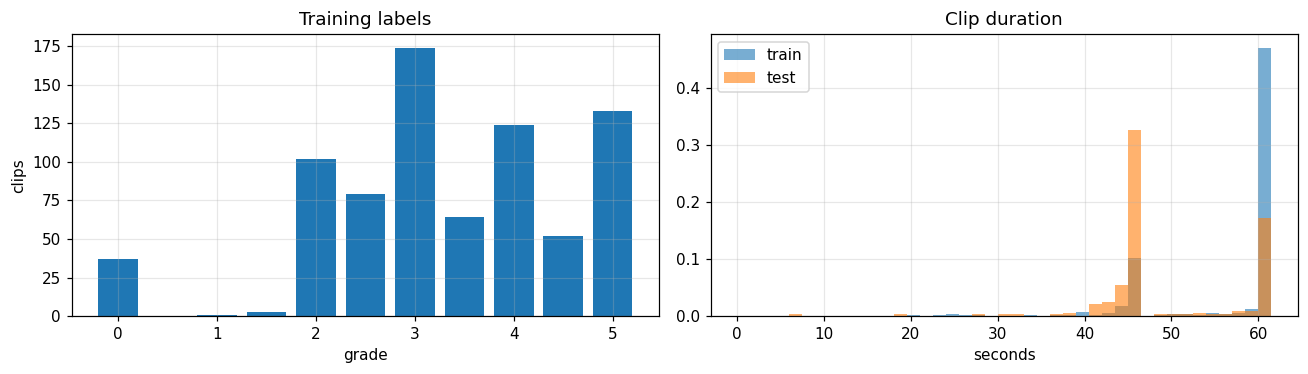

,train share,test share,"mean grade (train, >0)"
45 s,0.135,0.468,2.922
60 s,0.714,0.269,3.582
< 44 s,0.060,0.111,3.367
44-59 s,0.091,0.153,3.636


In [6]:
duration = pd.read_csv(FEAT / 'asr/audio_stats.csv').duration.to_numpy()


def batch(d):
    return np.where(np.abs(d - 45.06) < 0.1, 0, np.where(d > 59.5, 1, np.where(d < 44, 2, 3)))


BATCH = batch(duration)
BATCH_NAMES = ['45 s', '60 s', '< 44 s', '44-59 s']

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
counts = train.label.value_counts().sort_index()
ax[0].bar(counts.index, counts.values, width=0.4)
ax[0].set(title='Training labels', xlabel='grade', ylabel='clips')
bins = np.arange(0, 63, 1.5)
ax[1].hist(duration[:N_TRAIN], bins, density=True, alpha=0.6, label='train')
ax[1].hist(duration[N_TRAIN:], bins, density=True, alpha=0.6, label='test')
ax[1].set(title='Clip duration', xlabel='seconds')
ax[1].legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    'train share': np.bincount(BATCH[:N_TRAIN], minlength=4) / N_TRAIN,
    'test share': np.bincount(BATCH[N_TRAIN:], minlength=4) / len(test),
    'mean grade (train, >0)': [y_all[(BATCH[:N_TRAIN] == b) & (y_all > 0)].mean() for b in range(4)],
}, index=BATCH_NAMES).round(3)

In [7]:
import soundfile as sf
import librosa

# locate every wav (filenames repeat across train/test, so keep the split in the key)
WAVS = {'train': {}, 'test': {}}
for p in AUDIO_ROOT.rglob('*.wav'):
    WAVS['test' if 'test' in str(p.relative_to(AUDIO_ROOT)).lower() else 'train'][p.name] = p
CLIP_PATHS = [WAVS[k.split('/')[0]][k.split('/')[1]] for k in KEYS]      # KeyError here = set AUDIO_ROOT correctly


def noise_stats(path):
    x, sr = sf.read(path, dtype='float32')
    x = x.mean(1) if x.ndim > 1 else x
    if sr != 16000:
        x = librosa.resample(x, orig_sr=sr, target_sr=16000)
    db = 20 * np.log10(librosa.feature.rms(y=x, frame_length=400, hop_length=160)[0] + 1e-8)
    return dict(dyn_range=float(np.percentile(db, 95) - np.percentile(db, 5)),     # loud-vs-quiet contrast (dB)
                zcr=float(librosa.feature.zero_crossing_rate(x).mean()))           # high for broadband noise


STATS = WORK / 'noise_stats.csv'
if STATS.exists():
    wstats = pd.read_csv(STATS)
else:
    wstats = pd.DataFrame(Parallel(n_jobs=-1)(delayed(noise_stats)(p) for p in CLIP_PATHS))
    wstats.to_csv(STATS, index=False)

ZCR_MIN, DYN_MAX = 0.39, 10.0                      # both conditions must hold (one normal clip has a low dynamic range)
is_noise = ((wstats.zcr > ZCR_MIN) & (wstats.dyn_range < DYN_MAX)).to_numpy()
gate = is_noise                                    # replaces the old speech-ratio gate

agree = (is_noise[:N_TRAIN] == (y_all == 0)).mean()
print(f'train: guard flags {is_noise[:N_TRAIN].sum()} clips, label-0 clips {(y_all == 0).sum()}, agreement {agree:.1%}')
print('test : guard flags', list(test.filename[is_noise[N_TRAIN:]]))
assert agree == 1.0, 'noise guard and label-0 clips differ: revisit ZCR_MIN / DYN_MAX before trusting the gate'

zero, clean_tr, te = wstats[:N_TRAIN][y_all == 0], wstats[:N_TRAIN][y_all > 0], wstats[N_TRAIN:]
display(pd.DataFrame({'zcr min': [zero.zcr.min(), clean_tr.zcr.min(), te.zcr.min()], 'zcr max': [zero.zcr.max(), clean_tr.zcr.max(), te.zcr.max()],
                      'dyn min': [zero.dyn_range.min(), clean_tr.dyn_range.min(), te.dyn_range.min()],
                      'dyn max': [zero.dyn_range.max(), clean_tr.dyn_range.max(), te.dyn_range.max()]},
                     index=['train, grade 0', 'train, graded', 'test']).round(3))
print('audio_134.wav:', wstats.loc[N_TRAIN + list(test.filename).index('audio_134.wav')].round(3).to_dict(),
      '(the old speech-ratio gate zeroed this clip)')

nz = np.flatnonzero(y_all > 0)
y = y_all[nz]
B_TR, B_TE = BATCH[:N_TRAIN][nz], BATCH[N_TRAIN:]

train: guard flags 37 clips, label-0 clips 37, agreement 100.0%
test : guard flags []


,zcr min,zcr max,dyn min,dyn max
"train, grade 0",0.439,0.481,3.663,5.334
"train, graded",0.045,0.335,3.854,145.524
test,0.053,0.311,12.277,148.413


audio_134.wav: {'dyn_range': 13.319, 'zcr': 0.068} (the old speech-ratio gate zeroed this clip)


In [8]:
SPK_FILE = WORK / 'speaker_emb.npy'


def ecapa2_embeddings():
    from huggingface_hub import hf_hub_download
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = torch.jit.load(hf_hub_download('Jenthe/ECAPA2', 'ecapa2.pt'), map_location=dev).eval()
    unit = lambda a: a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-9)
    ch = 10 * 16000
    out = np.zeros((N, 192), np.float32)
    for i, path in enumerate(CLIP_PATHS):
        x, sr = sf.read(path, dtype='float32')
        x = x.mean(1) if x.ndim > 1 else x
        if sr != 16000:
            x = librosa.resample(x, orig_sr=sr, target_sr=16000)
        if len(x) < ch:
            x = np.tile(x, int(np.ceil(ch / max(len(x), 1))))[:ch]
        mid = (len(x) - ch) // 2
        chunks = [x[:ch], x[mid:mid + ch], x[-ch:]]                       # first, middle and last 10 s
        with torch.no_grad(), torch.jit.optimized_execution(False):
            e = np.vstack([model(torch.from_numpy(c[None]).to(dev)).float().cpu().numpy() for c in chunks])
        out[i] = unit(unit(e).mean(0))
    return out


def titanet_embeddings():                                                  # fallback: NeMo is already installed
    import nemo.collections.asr as nemo_asr
    m = nemo_asr.models.EncDecSpeakerLabelModel.from_pretrained('nvidia/speakerverification_en_titanet_large').eval()
    return np.vstack([m.get_embedding(str(p)).float().cpu().numpy().reshape(1, -1) for p in CLIP_PATHS])


if SPK_FILE.exists():
    E = np.load(SPK_FILE)
else:
    for fn in (ecapa2_embeddings, titanet_embeddings):
        try:
            E = fn()
            print('speaker embeddings from', fn.__name__)
            break
        except Exception as e:
            print(fn.__name__, 'failed:', repr(e)[:200])
    else:
        raise RuntimeError('no speaker model could be loaded (internet on? ECAPA2 comes from the Hugging Face hub)')
    np.save(SPK_FILE, E)
E = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
sim = E @ E.T

rows_clean, rows_test = nz, np.arange(N_TRAIN, N)


def cluster(rows, dist_thr):
    """Average-linkage clustering of cosine distance: clips closer than dist_thr are one speaker."""
    dist = 1 - np.clip(sim[np.ix_(rows, rows)], -1, 1)
    return AgglomerativeClustering(n_clusters=None, distance_threshold=dist_thr, metric='precomputed', linkage='average').fit_predict(dist)


# Test speakers never occur in train, so the share of test clips whose best TRAIN match is above the
# cut-off estimates how often two different people get merged at that cut-off.
best_test = sim[np.ix_(rows_test, rows_clean)].max(1)
rows = []
for thr in (0.2, 0.25, 0.3, 0.35):
    g = cluster(rows_clean, thr)
    sizes = np.bincount(g)
    multi = [k for k in range(len(sizes)) if sizes[k] > 1]
    rows.append({'distance cut-off': thr, 'train speakers': len(sizes), 'multi-clip speakers': len(multi),
                 'grade std inside a speaker': np.mean([y[g == k].std() for k in multi]),
                 'false-merge estimate': float((best_test > 1 - thr).mean())})
display(pd.DataFrame(rows).round(3))
print(f'grade std overall {y.std():.2f}; test best match to any train clip: max {best_test.max():.2f}')

SPK_DIST = 0.3                                     # pick from the table: low within-speaker std, false-merge estimate near 0
groups_nz = cluster(rows_clean, SPK_DIST)          # CV groups for the graded training clips (replaces the WavLM groups)
spk_test = cluster(rows_test, SPK_DIST)            # test speakers, used for pooling
te_size = pd.Series(spk_test).map(pd.Series(spk_test).value_counts()).to_numpy()
print(f'train: {len(set(groups_nz))} speakers in {len(y)} clips | test: {len(set(spk_test))} speakers, '
      f'{int((te_size > 1).sum())} of {len(rows_test)} clips share a speaker with another test clip')

ecapa2.pt: reconstructing file:   0%|          |  0.00B /  109MB            

ecapa2.pt: downloading bytes:           |  0.00B            

speaker embeddings from ecapa2_embeddings


,distance cut-off,train speakers,multi-clip speakers,grade std inside a speaker,false-merge estimate
0,0.20,431,193,0.155,0.000
1,0.25,407,200,0.157,0.005
2,0.30,388,201,0.168,0.023
3,0.35,377,198,0.173,0.083


grade std overall 1.01; test best match to any train clip: max 0.78
train: 388 speakers in 732 clips | test: 182 speakers, 55 of 216 clips share a speaker with another test clip


In [9]:
def grade_bins(v):
    b = np.round(v * 2).astype(int)
    b[b < 4] = 4
    return b


FOLDS = [list(StratifiedGroupKFold(5, shuffle=True, random_state=s).split(nz, grade_bins(y), groups_nz)) for s in range(3)]
RANDOM_FOLDS = [list(StratifiedKFold(5, shuffle=True, random_state=s).split(nz, grade_bins(y))) for s in range(3)]


def cross_val(model, X, folds=FOLDS, refit=False):
    """Out-of-fold predictions (3 repeats x graded clips) and test predictions.
    Test predictions are the mean of the 15 fold models, or a refit on all graded clips if refit=True (TabPFN client)."""
    X_tr, X_te = X[:N_TRAIN][nz], X[N_TRAIN:]

    def fit(r, tr, va):
        m = clone(model).fit(X_tr[tr], y[tr])
        t = None if refit else m.predict(X_te)
        return r, va, m.predict(X_tr[va]), t

    oof, pred = np.zeros((len(folds), len(y))), np.zeros(len(X_te))
    runs = Parallel(n_jobs=1 if refit else -1)(delayed(fit)(r, tr, va) for r, fold in enumerate(folds) for tr, va in fold)
    for r, va, p, t in runs:
        oof[r, va] = p
        if t is not None:
            pred += t / len(runs)
    if refit:
        pred = clone(model).fit(X_tr, y).predict(X_te)
    return np.clip(oof, 1, 5), np.clip(pred, 1, 5)


def score(oof):
    return float(np.mean([rmse(o, y) for o in oof]))


whisper_enc = np.load(FEAT / 'speech/whisperenc_mean.npy').astype(np.float32)
demo = make_pipeline(StandardScaler(), SVR(C=10, epsilon=0.1))
print('Whisper encoder layer 22 + SVR')
print(f'  random folds : {score(cross_val(demo, whisper_enc[:, 22], RANDOM_FOLDS)[0]):.3f}')
print(f'  speaker folds: {score(cross_val(demo, whisper_enc[:, 22])[0]):.3f}')

Whisper encoder layer 22 + SVR
  random folds : 0.522
  speaker folds: 0.606


In [10]:
# ---------- which question did the speaker answer? (MPNet clusters of the transcripts) ----------
PE = np.load(FEAT / 'text_enc/prompt_mpnet.npy').astype(np.float32)
PE = PE[reorder(json.load(open(FEAT / 'text_enc/keys.json')))]
PE /= np.linalg.norm(PE, axis=1, keepdims=True) + 1e-9

K_PROMPTS = 10
topic = KMeans(K_PROMPTS, n_init=10, random_state=0).fit_predict(PE)
topic_tr, topic_te = topic[:N_TRAIN][nz], topic[N_TRAIN:]
display(pd.DataFrame({'train clips': np.bincount(topic_tr, minlength=K_PROMPTS),
                      'test clips': np.bincount(topic_te, minlength=K_PROMPTS)}).T)


def prompt_folds():
    """Hold out one prompt group at a time; the speakers who appear in it are also removed from training."""
    out = []
    for t in sorted(set(topic_tr)):
        va = np.flatnonzero(topic_tr == t)
        tr = np.flatnonzero((topic_tr != t) & ~np.isin(groups_nz, groups_nz[va]))
        out.append((tr, va))
    return out


PROMPT_FOLDS = [prompt_folds()]        # one repeat; every graded clip is held out exactly once

,0,1,2,3,4,5,6,7,8,9
train clips,139,13,100,118,100,99,91,29,0,43
test clips,14,59,10,11,19,20,28,27,22,6


In [11]:
def mean_of_layers(E, layers):
    return E[:, layers].mean(1)


def llm_hidden(tag, variant, kind):
    E = np.load(FEAT / f'text_llm/{tag}__{variant}__grammar__{kind}.npy').astype(np.float32)
    return E[reorder(json.load(open(FEAT / f'text_llm/keys_{variant}.json')))]


def llm_probs(tag, variants):
    blocks = []
    for v in variants:
        order = reorder(json.load(open(FEAT / f'text_llm/keys_{v}.json')))
        for prompt in ['grammar', 'vocab', 'coherence', 'cefr', 'errors']:
            P = np.load(FEAT / f'text_llm/{tag}__{v}__{prompt}__probs.npy')[order]
            k = P.shape[1] - 1                                   # last column is the probability mass on digits
            blocks.append(np.hstack([P[:, :k], (P[:, :k] * np.arange(1, k + 1)).sum(1, keepdims=True)]))
    return np.hstack(blocks)


TEXT_LAYERS = {'roberta': [12, 16, 20, 24], 'electra': [12, 16, 20, 24], 'deberta': [12, 16, 20, 24]}   # as in extract_features.py


def text_enc_views(tag, layers):
    E = np.load(FEAT / f'text_enc/{tag}.npy').astype(np.float32)
    E = E[reorder(json.load(open(FEAT / 'text_enc/keys.json')))]
    return {f'{tag}_L{l}': E[:, i] for i, l in enumerate(layers)}


whisper_enc = np.load(FEAT / 'speech/whisperenc_mean.npy').astype(np.float32)        # (clips, 33 layers, 1280)
wavlm_mean = np.load(FEAT / 'speech/wavlm_mean.npy').astype(np.float32)              # (clips, 25 layers, 1024)
vox = np.load(FEAT / 'audio_llm/vox_amean.npy').astype(np.float32)                   # (clips, 6 layers, 3072): layers ~9, 14, 18, 22, 27, 30
wdec = np.load(FEAT / 'decoder/wdec_verbatim_mean.npy').astype(np.float32)
wdec_pk = np.load(FEAT / 'decoder/wdec_parakeet_mean.npy').astype(np.float32)
q7_verbatim = llm_hidden('Qwen2.5-7B-Instruct', 'verbatim', 'mean')                 # (clips, 7 layers, 3584): layers 7, 11, 14, 17, 21, 25, 28
q7_plain_mean = llm_hidden('Qwen2.5-7B-Instruct', 'plain', 'mean')
hand = pd.read_csv(FEAT / 'hand_features.csv').set_index('key')
probs = llm_probs('Qwen2.5-7B-Instruct', ['verbatim', 'plain'])
gi = pd.read_csv(FEAT / 'grammar_inst.csv').set_index('key').loc[KEYS].values        # CoLA / ELECTRA / T5 instruments

X = {
    'whisper_enc': mean_of_layers(whisper_enc, [30, 31, 32]),
    'wavlm': mean_of_layers(wavlm_mean, [19, 20, 21]),
    'whisper_dec': mean_of_layers(wdec, [20, 21, 22]),
    'whisper_dec_pk': mean_of_layers(wdec_pk, [7, 8, 9]),
    'whisper_dec_pk_L9': wdec_pk[:, 9],
    'voxtral': mean_of_layers(vox, [0, 1]),
    'voxtral_L14': vox[:, 1],
    'qwen7b_L17': q7_verbatim[:, 3],
    'qwen7b_L21': q7_verbatim[:, 4],
    'qwen7b_plain_L17': q7_plain_mean[:, 3],
    'hand': np.hstack([hand.loc[KEYS].values, probs, gi]),
}
X.update({f'whisper_enc_L{l}': whisper_enc[:, l] for l in (20, 24, 28, 32)})
X.update({f'wavlm_L{l}': wavlm_mean[:, l] for l in (15, 18, 21, 24)})
X.update({f'voxtral_i{k}': vox[:, k] for k in (0, 2, 3, 4, 5)})
X.update({f'qwen7b_i{k}': q7_verbatim[:, k] for k in (2, 5)})
for tag, layers in TEXT_LAYERS.items():
    X.update(text_enc_views(tag, layers))

# fusion views: concatenations of the views above (one SVR sees audio, transcript and hand features together)
FUSIONS = {
    'fuse_audio': ('voxtral_L14', 'whisper_enc'),
    'fuse_enc_hand': ('whisper_enc', 'voxtral_L14', 'hand'),
    'fuse_audio_txt': ('voxtral_L14', 'whisper_dec', 'qwen7b_L17'),
    'fuse_audio_txt_hand': ('voxtral_L14', 'whisper_dec', 'qwen7b_L17', 'hand'),
    'fuse_wide': ('whisper_enc', 'wavlm', 'voxtral_L14', 'whisper_dec_pk', 'qwen7b_L17', 'hand'),     # 14B replaced by 7B
    'fuse_whisper_roberta': ('whisper_enc', 'roberta_L20', 'hand'),                                   # notebook 1's best recipe
    'fuse_voxtral_roberta': ('voxtral_L14', 'roberta_L20', 'hand'),
    'fuse_wide_txt': ('whisper_enc', 'wavlm', 'voxtral_L14', 'whisper_dec_pk', 'qwen7b_L17', 'roberta_L20', 'hand'),
    'fuse_all_enc': ('whisper_enc', 'wavlm', 'voxtral_L14', 'roberta_L20', 'deberta_L20', 'electra_L16', 'hand'),
}
FUSION_DIMS = {}
for fname, parts in FUSIONS.items():
    X[fname] = np.hstack([X[p] for p in parts])
    FUSION_DIMS[fname] = tuple(X[p].shape[1] for p in parts)

pd.DataFrame({'dimensions': {k: v.shape[1] for k, v in X.items()}})

,dimensions
whisper_enc,1280
wavlm,1024
whisper_dec,1280
whisper_dec_pk,1280
whisper_dec_pk_L9,1280
voxtral,3072
voxtral_L14,3072
qwen7b_L17,3584
qwen7b_L21,3584
qwen7b_plain_L17,3584


In [12]:
!pip install -q tabpfn-client

TabPFN client ready, token length 53
72 of 87 base models kept (CV RMSE < 0.63)


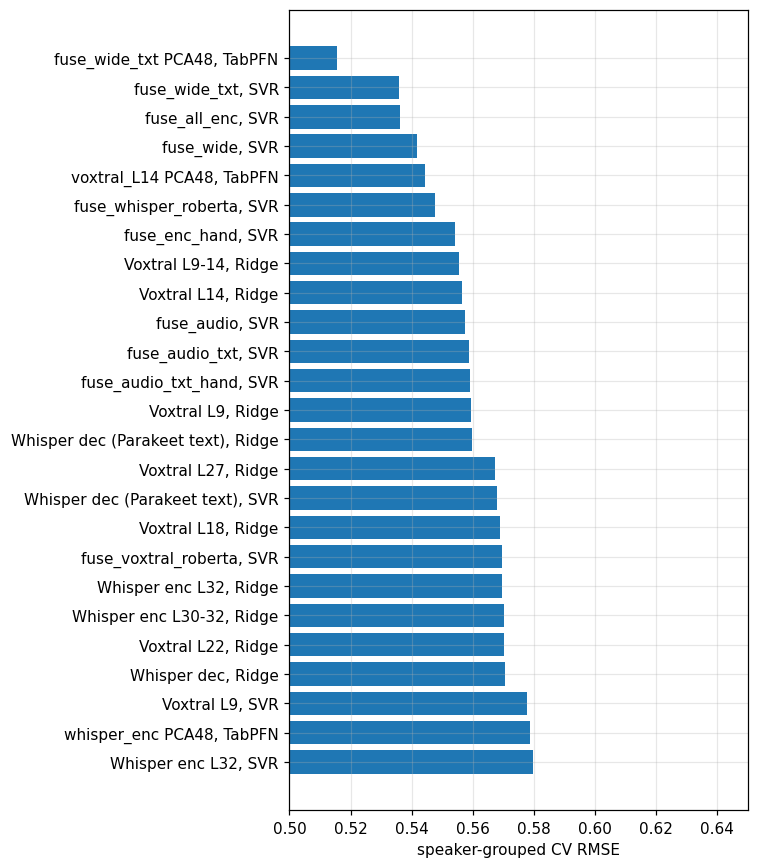

,CV RMSE,Pearson
"fuse_wide_txt PCA48, TabPFN",0.5156,0.8615
"fuse_wide_txt, SVR",0.5358,0.8519
"fuse_all_enc, SVR",0.5362,0.8516
"fuse_wide, SVR",0.5417,0.8485
"voxtral_L14 PCA48, TabPFN",0.5444,0.8436
"fuse_whisper_roberta, SVR",0.5476,0.8431
"fuse_enc_hand, SVR",0.5541,0.8397
"Voxtral L9-14, Ridge",0.5556,0.8379
"Voxtral L14, Ridge",0.5563,0.8378
"fuse_audio, SVR",0.5574,0.8380


In [13]:
USE_TABPFN = True
try:
    from kaggle_secrets import UserSecretsClient
    from tabpfn_client import TabPFNRegressor, set_access_token
    token = UserSecretsClient().get_secret('TABPFN_TOKEN')
    os.environ['TABPFN_TOKEN'] = token
    set_access_token(token)
    print('TabPFN client ready, token length', len(token))
except Exception as e:                                   # loud, but the run continues without the TabPFN models
    USE_TABPFN = False
    print('!!! TabPFN SKIPPED:', repr(e)[:300])

from joblib.externals.loky import get_reusable_executor
get_reusable_executor().shutdown(wait=True)              # drop loky workers that carry a stale environment


class BlockWeight(BaseEstimator, TransformerMixin):
    """After standardising, rescale each concatenated block so that every block carries the same total variance."""

    def __init__(self, dims=()):
        self.dims = dims

    def fit(self, X, y=None):
        D, k = sum(self.dims), len(self.dims)
        self.scale_ = np.concatenate([np.full(d, np.sqrt(D / (k * d))) for d in self.dims]).astype(np.float32)
        return self

    def transform(self, X):
        return X * self.scale_


class PCAThenTabPFN(BaseEstimator, RegressorMixin):
    """Standardise, project onto a few principal components (fitted on the training fold only), then TabPFN through the
    client API. The API takes at most ~500 features, so wide embeddings are reduced first."""

    def __init__(self, n_components=48):
        self.n_components = n_components

    def fit(self, X, y):
        self.sc_ = StandardScaler().fit(X)
        self.pca_ = PCA(self.n_components, random_state=0).fit(self.sc_.transform(X))
        self.m_ = TabPFNRegressor()
        self.m_.fit(self.pca_.transform(self.sc_.transform(X)), y)
        return self

    def predict(self, X):
        return self.m_.predict(self.pca_.transform(self.sc_.transform(X)))


def ridge(alpha, d):
    return make_pipeline(StandardScaler(), Ridge(alpha=alpha * d))


def svr(C, d):
    return make_pipeline(StandardScaler(), SVR(C=C, gamma=1.0 / d, epsilon=0.1))


def fusion_svr(name, C=3):
    dims = FUSION_DIMS[name]
    return make_pipeline(StandardScaler(), BlockWeight(dims), SVR(C=C, gamma=1.0 / sum(dims), epsilon=0.1))


# item 2: several layers of every kept network, each read out by both Ridge and SVR
LAYERED = {
    'whisper_enc': 'Whisper enc L30-32', 'whisper_enc_L20': 'Whisper enc L20', 'whisper_enc_L24': 'Whisper enc L24',
    'whisper_enc_L28': 'Whisper enc L28', 'whisper_enc_L32': 'Whisper enc L32',
    'wavlm': 'WavLM L19-21', 'wavlm_L15': 'WavLM L15', 'wavlm_L18': 'WavLM L18', 'wavlm_L21': 'WavLM L21', 'wavlm_L24': 'WavLM L24',
    'whisper_dec': 'Whisper dec', 'whisper_dec_pk': 'Whisper dec (Parakeet text)',
    'voxtral': 'Voxtral L9-14', 'voxtral_i0': 'Voxtral L9', 'voxtral_L14': 'Voxtral L14', 'voxtral_i2': 'Voxtral L18',
    'voxtral_i3': 'Voxtral L22', 'voxtral_i4': 'Voxtral L27', 'voxtral_i5': 'Voxtral L30',
    'qwen7b_i2': 'Qwen2.5-7B L14', 'qwen7b_L17': 'Qwen2.5-7B L17', 'qwen7b_L21': 'Qwen2.5-7B L21', 'qwen7b_i5': 'Qwen2.5-7B L25',
    'qwen7b_plain_L17': 'Qwen2.5-7B L17 (plain ASR)',
}
for tag, layers in TEXT_LAYERS.items():                                   # item 1: transcript encoders
    LAYERED.update({f'{tag}_L{l}': f'{tag.capitalize()} L{l}' for l in layers})

d = {k: v.shape[1] for k, v in X.items()}
MODELS = {}
for view, label in LAYERED.items():
    MODELS[f'{label}, Ridge'] = (view, ridge(1.0, d[view]))
    MODELS[f'{label}, SVR'] = (view, svr(3, d[view]))
for f in FUSIONS:
    MODELS[f'{f}, SVR'] = (f, fusion_svr(f))

# TabPFN through the client API: tabular features directly, embeddings after a PCA fitted inside each fold.
# Each model costs 16 API fits (15 folds + 1 refit), so keep this list short if your API quota is small.
TABPFN_PCA_VIEWS = ['whisper_enc', 'voxtral_L14', 'roberta_L20', 'qwen7b_L17', 'fuse_wide_txt']
if USE_TABPFN:
    MODELS['hand + grammar instruments, TabPFN'] = ('hand', TabPFNRegressor())
    for v in TABPFN_PCA_VIEWS:
        MODELS[f'{v} PCA48, TabPFN'] = (v, PCAThenTabPFN(48))
TABPFN_NAMES = [n for n in MODELS if n.endswith('TabPFN')]

# cache: base-model predictions are expensive (TabPFN API calls); delete this file if you change a model's settings
FP = hashlib.md5(groups_nz.tobytes() + nz.tobytes()).hexdigest()[:8]
CACHE = WORK / f'base_cache_v2_{FP}.pkl'
cache = joblib.load(CACHE) if CACHE.exists() else {}
for name, (src, model) in MODELS.items():
    if name not in cache:
        cache[name] = cross_val(model, X[src], refit=name in TABPFN_NAMES)
        joblib.dump(cache, CACHE)

results_all = pd.DataFrame({
    'CV RMSE': {n: score(cache[n][0]) for n in MODELS},
    'Pearson': {n: np.mean([pearsonr(r, y)[0] for r in cache[n][0]]) for n in MODELS},
}).sort_values('CV RMSE')

# item 3: prune weak models (selection on the same CV, as in notebook 1's 48-model stack)
PRUNE_AT = 0.63
NAMES = [n for n in results_all.index if results_all.loc[n, 'CV RMSE'] < PRUNE_AT]
if len(NAMES) < 8:
    NAMES = list(results_all.index[:8])
print(f'{len(NAMES)} of {len(MODELS)} base models kept (CV RMSE < {PRUNE_AT})')
OOF = {n: cache[n][0] for n in NAMES}
TEST = {n: cache[n][1] for n in NAMES}
results = results_all.loc[NAMES]

top = results.head(25)
plt.figure(figsize=(7, 8))
plt.barh(top.index[::-1], top['CV RMSE'][::-1])
plt.xlim(0.5, 0.65)
plt.xlabel('speaker-grouped CV RMSE')
plt.tight_layout()
plt.show()
results_all.head(15).round(4)

In [14]:
# ---------- non-negative stacker (weights shrunk toward a prior) ----------
def nnls_fit(P, t, shrink=0.0, prior=None):
    """Non-negative weights and a free intercept. shrink > 0 adds an L2 pull of the weights toward `prior`
    (equal weights 1/k by default): minimises MSE + shrink * ||w - prior||^2."""
    k = P.shape[1]
    mu, tb = P.mean(0), t.mean()
    prior = np.full(k, 1.0 / k) if prior is None else prior
    A, b = P - mu, t - tb
    if shrink > 0:
        s = np.sqrt(shrink * len(t))
        A, b = np.vstack([A, s * np.eye(k)]), np.r_[b, s * prior]
    w, _ = nnls(A, b)
    return w, tb - mu @ w


def nnls_stack(P_fit, t_fit, b_fit, P_new, b_new, mode='split', shrink=0.1, batch_shrink=0.3):
    """mode 'global'      : one fit for every clip
       mode 'split'       : separate fits for the 45 s batch and the rest, each shrunk toward equal weights
       mode 'split_global': the same split, but each batch fit is shrunk toward the global weights"""
    w_g, c_g = nnls_fit(P_fit, t_fit, shrink)
    out, W = P_new @ w_g + c_g, {'global': w_g}
    if mode == 'global':
        return out, W
    for is_45, tag in ((True, '45 s'), (False, 'other')):
        fr, nr = (b_fit == 0) == is_45, (b_new == 0) == is_45
        if not nr.any() or fr.sum() < 20:
            continue
        w, c = nnls_fit(P_fit[fr], t_fit[fr], batch_shrink if mode == 'split_global' else shrink, w_g if mode == 'split_global' else None)
        out[nr], W[tag] = P_new[nr] @ w + c, w
    return out, W


# ---------- ordinal Sin-SMFL head (cumulative thresholds at grade > 1, > 2, > 3, > 4) ----------
K = 4
THR = torch.arange(1, K + 1, dtype=torch.float32)          # grade >= 1 holds for every clip, so no constant threshold


def soft_targets(yv):
    return (torch.as_tensor(yv, dtype=torch.float32)[:, None] - THR[None]).clamp(0, 1)


def effective_number_weights(T, beta=0.999):
    n = T.sum(0).clamp(min=1.0)
    a = (1 - beta) / (1 - beta ** n)
    return a / a.mean()


def smfl_loss(logits, T, alpha):
    p = torch.sigmoid(logits)
    pt = p * T + (1 - p) * (1 - T)
    mod = torch.sin(math.pi / 2 * (1 - pt).clamp(0, 1)) ** 2
    bce = F.binary_cross_entropy_with_logits(logits, T, reduction='none')
    return (alpha * mod * bce).sum() / T.sum().clamp(min=1.0)


class OrdHead(nn.Module):
    def __init__(self, dim, T_mean, dropout=0.1):
        super().__init__()
        self.drop, self.out = nn.Dropout(dropout), nn.Linear(dim, K)
        nn.init.normal_(self.out.weight, std=1e-3)
        with torch.no_grad():
            self.out.bias.copy_(torch.logit(T_mean.clamp(0.02, 0.98)))

    def forward(self, x):
        return self.out(self.drop(x))


def grade_of(head, A):
    return 1 + torch.sigmoid(head(A)).sum(-1)


def train_ord_head(Xtr, ytr, gtr, seed, epochs=100, lr=1e-2, wd=1e-2):
    """Early stopping uses a validation split that keeps every speaker (and every repeat of a clip) on one side."""
    torch.manual_seed(seed)
    a, b = next(GroupShuffleSplit(1, test_size=0.15, random_state=seed).split(Xtr, groups=gtr))
    Xt, Xv = torch.tensor(Xtr[a], dtype=torch.float32), torch.tensor(Xtr[b], dtype=torch.float32)
    yt, yv = torch.tensor(ytr[a], dtype=torch.float32), torch.tensor(ytr[b], dtype=torch.float32)
    Tt = soft_targets(ytr[a])
    alpha = effective_number_weights(Tt)
    head = OrdHead(Xt.shape[1], Tt.mean(0))
    opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best, state = float('inf'), copy.deepcopy(head.state_dict())
    for _ in range(epochs):
        head.train()
        lg = head(Xt)
        loss = 2.0 * smfl_loss(lg, Tt, alpha) + F.mse_loss(1 + torch.sigmoid(lg).sum(-1), yt)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        head.eval()
        with torch.no_grad():
            v = F.mse_loss(grade_of(head, Xv), yv).item()
        if v < best:
            best, state = v, copy.deepcopy(head.state_dict())
    head.load_state_dict(state)
    return head.eval()


def ord_stack(P_fit, t_fit, g_fit, b_fit, P_new, b_new, seeds=(0, 1, 2)):
    """One head on all clips (a 45 s indicator column replaces the second per-batch head: its validation split
    would hold ~12 clips). Averaged over a few seeds."""
    A_fit, A_new = np.column_stack([P_fit, b_fit == 0]), np.column_stack([P_new, b_new == 0])
    sc = StandardScaler().fit(A_fit)
    A_fit, A_new = sc.transform(A_fit), sc.transform(A_new)
    out = np.zeros(len(P_new))
    for s in seeds:
        head = train_ord_head(A_fit, t_fit, g_fit, s)
        with torch.no_grad():
            out += grade_of(head, torch.tensor(A_new, dtype=torch.float32)).numpy() / len(seeds)
    return out

In [15]:
P_rep = [np.stack([OOF[n][r] for n in NAMES], 1) for r in range(3)]          # (graded clips x models) per repeat
P_mean = np.mean(P_rep, 0)                                                   # one row per clip: used for the final fit


def crossfit(fn):
    """Out-of-fold stack predictions: every fold is predicted by a stacker fitted on the other folds' OOF rows."""
    out = np.zeros((3, len(y)))
    for r in range(3):
        for tr, va in FOLDS[r]:
            out[r, va] = fn(P_rep[r][tr], y[tr], groups_nz[tr], B_TR[tr], P_rep[r][va], B_TR[va])
    return out


# item 5: the same models predicted under held-out-prompt folds (TabPFN API models left out to save calls)
NAMES_P = [n for n in NAMES if n not in TABPFN_NAMES]
PCACHE = WORK / f'prompt_cache_v2_{FP}.pkl'
pcache = joblib.load(PCACHE) if PCACHE.exists() else {}
for n in NAMES_P:
    if n not in pcache:
        pcache[n] = cross_val(MODELS[n][1], X[MODELS[n][0]], folds=PROMPT_FOLDS)[0]
joblib.dump(pcache, PCACHE)
P_prompt = np.stack([pcache[n][0] for n in NAMES_P], 1)


def crossfit_prompt(fn):
    out = np.zeros(len(y))
    for tr, va in PROMPT_FOLDS[0]:
        out[va] = fn(P_prompt[tr], y[tr], groups_nz[tr], B_TR[tr], P_prompt[va], B_TR[va])
    return out


# item 6: a second NNLS stack (global weights) averaged with the split one
_SPLIT, _GLOBAL = dict(mode='split', shrink=0.1), dict(mode='global', shrink=0.1)
CONFIGS = {
    'global, no shrink': [dict(mode='global', shrink=0.0)],
    'global, shrink 0.1': [_GLOBAL],
    'split 45 s / rest, no shrink (old)': [dict(mode='split', shrink=0.0)],
    'split, shrink 0.1': [_SPLIT],
    'split, shrink 0.3': [dict(mode='split', shrink=0.3)],
    'split -> global, 0.3': [dict(mode='split_global', shrink=0.1, batch_shrink=0.3)],
    'average: split + global, shrink 0.1': [_SPLIT, _GLOBAL],
}


def nn_multi(cfgs, Pf, tf, bf, Pn, bn):
    return np.mean([nnls_stack(Pf, tf, bf, Pn, bn, **c)[0] for c in cfgs], 0)


NN_OOF = {k: crossfit(lambda Pf, tf, gf, bf, Pn, bn, c=c: nn_multi(c, Pf, tf, bf, Pn, bn)) for k, c in CONFIGS.items()}
NN_PROMPT = {k: crossfit_prompt(lambda Pf, tf, gf, bf, Pn, bn, c=c: nn_multi(c, Pf, tf, bf, Pn, bn)) for k, c in CONFIGS.items()}
ORD_OOF = crossfit(lambda Pf, tf, gf, bf, Pn, bn: ord_stack(Pf, tf, gf, bf, Pn, bn))
ORD_PROMPT = crossfit_prompt(lambda Pf, tf, gf, bf, Pn, bn: ord_stack(Pf, tf, gf, bf, Pn, bn, seeds=(0,)))
EQUAL_OOF = np.stack([P.mean(1) for P in P_rep])
EQUAL_PROMPT = P_prompt.mean(1)


def row(name, o, o_p):
    o = np.clip(o, 1, 5)
    return {'stack': name, 'CV RMSE': score(o), '45 s clips': np.mean([rmse(r[B_TR == 0], y[B_TR == 0]) for r in o]),
            'Pearson': np.mean([pearsonr(r, y)[0] for r in o]), 'held-out-prompt RMSE': rmse(np.clip(o_p, 1, 5), y)}


def sel_score(k, w=0.0):
    """Settings are chosen on the average of speaker-grouped and held-out-prompt RMSE."""
    spk = score(np.clip((1 - w) * NN_OOF[k] + w * ORD_OOF, 1, 5))
    prm = rmse(np.clip((1 - w) * NN_PROMPT[k] + w * ORD_PROMPT, 1, 5), y)
    return 0.5 * (spk + prm)


best_nn = min(NN_OOF, key=sel_score)
table = [row('equal-weight mean of all models', EQUAL_OOF, EQUAL_PROMPT)] + [row(k, NN_OOF[k], NN_PROMPT[k]) for k in CONFIGS]
table += [row('ordinal head only', ORD_OOF, ORD_PROMPT)]
table += [row(f'{best_nn} + {w:.2f} ordinal', (1 - w) * NN_OOF[best_nn] + w * ORD_OOF, (1 - w) * NN_PROMPT[best_nn] + w * ORD_PROMPT) for w in (0.25, 0.5)]
ablation = pd.DataFrame(table).set_index('stack').round(4)
display(ablation)

W_GRID = (0.0, 0.25, 0.5, 0.75, 1.0)
w_scores = {w: sel_score(best_nn, w) for w in W_GRID}
W_ORD = min(w_scores, key=w_scores.get)
if w_scores[0.0] - w_scores[W_ORD] < 0.002:                # the ordinal head is kept only if it clearly helps
    W_ORD = 0.0
BEST_CFGS = CONFIGS[best_nn]
print(f'chosen NNLS configuration: {best_nn} | ordinal weight {W_ORD} | selection scores {({k: round(v, 4) for k, v in w_scores.items()})}')
stack_oof = np.clip((1 - W_ORD) * NN_OOF[best_nn] + W_ORD * ORD_OOF, 1, 5)
print(f'stack CV RMSE {score(stack_oof):.4f}, Pearson {np.mean([pearsonr(p, y)[0] for p in stack_oof]):.4f} '
      f'(best single model {results["CV RMSE"].min():.4f})')

,CV RMSE,45 s clips,Pearson,held-out-prompt RMSE
stack,,,,
equal-weight mean of all models,0.5306,0.5568,0.8627,0.5665
"global, no shrink",0.5147,0.5367,0.8615,0.5328
"global, shrink 0.1",0.5130,0.5375,0.8625,0.5290
"split 45 s / rest, no shrink (old)",0.5160,0.5462,0.8609,0.5251
"split, shrink 0.1",0.5122,0.5348,0.8630,0.5223
"split, shrink 0.3",0.5119,0.5336,0.8632,0.5220
"split -> global, 0.3",0.5120,0.5311,0.8631,0.5219
"average: split + global, shrink 0.1",0.5112,0.5288,0.8635,0.5234
ordinal head only,0.5145,0.5322,0.8621,0.5251


chosen NNLS configuration: split, shrink 0.3 | ordinal weight 0.5 | selection scores {0.0: 0.517, 0.25: 0.5144, 0.5: 0.5138, 0.75: 0.5155, 1.0: 0.5198}
stack CV RMSE 0.5085, Pearson 0.8652 (best single model 0.5156)


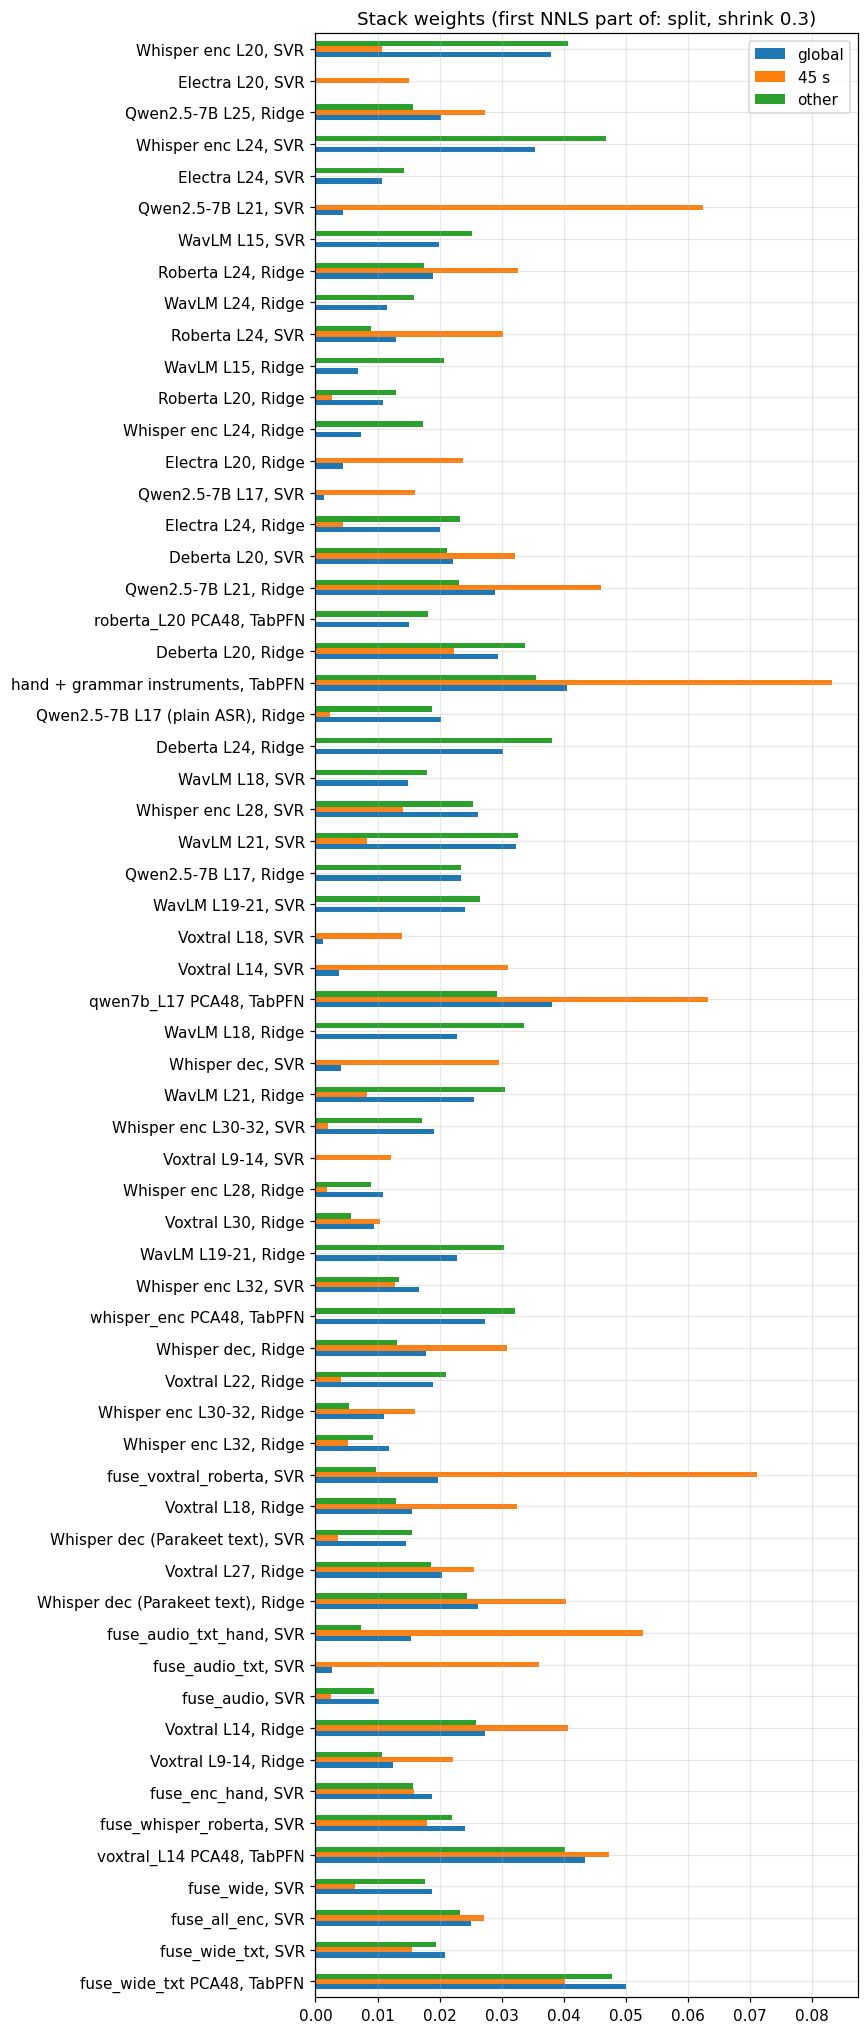

,batch,clips,RMSE,Pearson
0,45 s,103,0.520,0.764
1,60 s,518,0.508,0.869
2,< 44 s,45,0.514,0.807
3,44-59 s,66,0.437,0.908


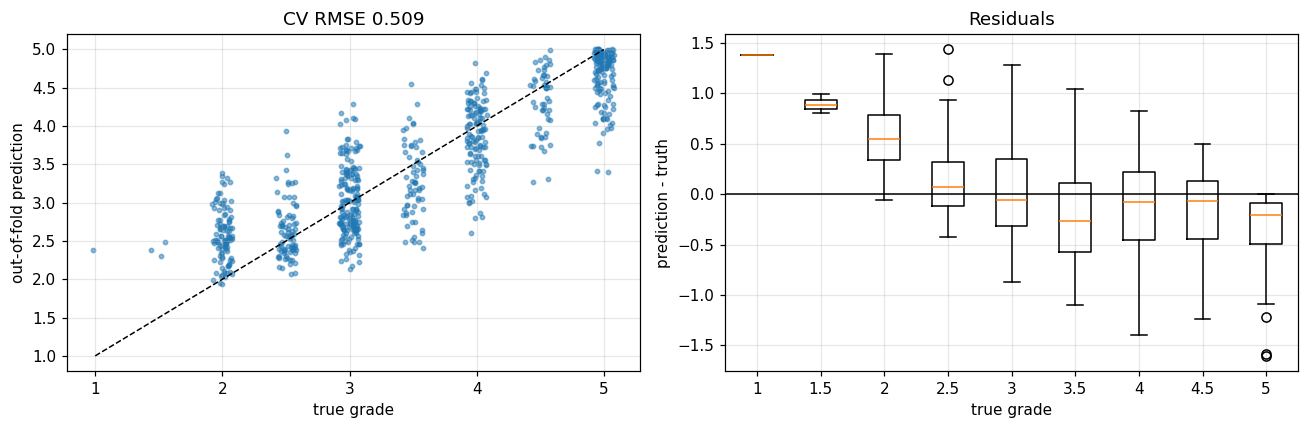

In [16]:
# final stacker: fitted once on the repeat-averaged out-of-fold predictions (each clip appears once)
T = np.stack([TEST[n] for n in NAMES], 1)
nn_test = nn_multi(BEST_CFGS, P_mean, y, B_TR, T, B_TE)
W_FINAL = nnls_stack(P_mean, y, B_TR, T, B_TE, **BEST_CFGS[0])[1]
ord_test = ord_stack(P_mean, y, groups_nz, B_TR, T, B_TE) if W_ORD > 0 else np.zeros(len(T))
stack_test = (1 - W_ORD) * nn_test + W_ORD * ord_test

weights = pd.DataFrame(W_FINAL, index=NAMES)
weights = weights[weights.max(1) > 0.01]                     # only models that carry weight
weights.plot.barh(figsize=(8, max(4, 0.3 * len(weights))), title=f'Stack weights (first NNLS part of: {best_nn})')
plt.tight_layout()
plt.show()

p = stack_oof.mean(0)
display(pd.DataFrame([{'batch': BATCH_NAMES[b], 'clips': (B_TR == b).sum(), 'RMSE': rmse(p[B_TR == b], y[B_TR == b]),
                       'Pearson': pearsonr(p[B_TR == b], y[B_TR == b])[0]} for b in range(4)]).round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(y))
ax[0].scatter(y + jitter, p, s=8, alpha=0.5)
ax[0].plot([1, 5], [1, 5], 'k--', lw=1)
ax[0].set(xlabel='true grade', ylabel='out-of-fold prediction', title=f'CV RMSE {score(stack_oof):.3f}')
levels = np.unique(y)
ax[1].boxplot([p[y == v] - v for v in levels])
ax[1].set_xticks(range(1, len(levels) + 1), [f'{v:g}' for v in levels])
ax[1].axhline(0, color='k', lw=1)
ax[1].set(xlabel='true grade', ylabel='prediction - truth', title='Residuals')
plt.tight_layout()
plt.show()

In [17]:
def pool_speaker(p, spk, lam):
    """Move each prediction a fraction lam of the way toward the mean prediction of the same speaker's clips."""
    return p + lam * (pd.Series(p).groupby(spk).transform('mean').to_numpy() - p)


def finish(raw, spk, lam):
    return np.clip(pool_speaker(raw, spk, lam), 1, 5)


# Validation: the CV folds are grouped by these same speaker clusters, so a cluster is never split across folds
# and pooling the out-of-fold predictions per cluster is exactly what pooling does on the test set.
raw_oof = (1 - W_ORD) * NN_OOF[best_nn] + W_ORD * ORD_OOF
size = pd.Series(groups_nz).map(pd.Series(groups_nz).value_counts()).to_numpy()
LAMS = (0.0, 0.2, 0.3, 0.4, 0.5, 0.65, 0.8, 1.0)
pool_tab = pd.DataFrame({lam: {'all graded clips': score(np.stack([finish(r, groups_nz, lam) for r in raw_oof])),
                               **{f'speakers with {k} clips': np.mean([rmse(finish(r, groups_nz, lam)[size == k], y[size == k]) for r in raw_oof])
                                  for k in (1, 2, 3)}} for lam in LAMS}).T
display(pool_tab.round(4))

LAM = min((l for l in LAMS if l <= 0.5), key=lambda l: pool_tab.loc[l, 'all graded clips'])      # strengths above 0.5 are not supported by CV
share_test = float((te_size > 1).mean())
share_train = float((size > 1).mean())
print(f'pooling strength {LAM}. Multi-clip speakers are {share_train:.0%} of graded train clips but only {share_test:.0%} of test clips, '
      f'so expect roughly {share_test / share_train:.0%} of the CV gain on the test set.')

,all graded clips,speakers with 1 clips,speakers with 2 clips,speakers with 3 clips
0.00,0.5085,0.5466,0.4683,0.5009
0.20,0.5050,0.5466,0.4665,0.4952
0.30,0.5041,0.5466,0.4666,0.4936
0.40,0.5039,0.5466,0.4674,0.4928
0.50,0.5043,0.5466,0.4688,0.4929
0.65,0.5060,0.5466,0.4722,0.4945
0.80,0.5091,0.5466,0.4771,0.4981
1.00,0.5153,0.5466,0.4857,0.5056


pooling strength 0.4. Multi-clip speakers are 74% of graded train clips but only 25% of test clips, so expect roughly 34% of the CV gain on the test set.


zeros written: 0 | audio_134.wav -> 2.0354


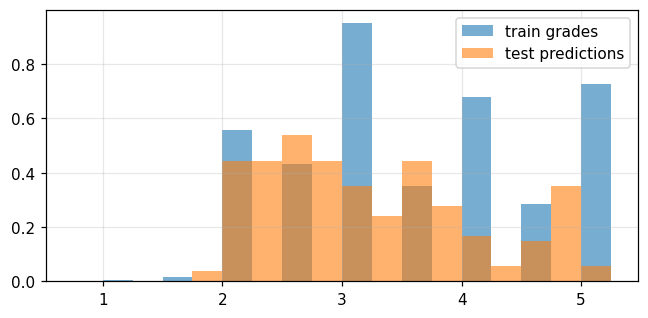

,count,mean,std,min,25%,50%,75%,max
label,216.0,3.252,0.868,1.943,2.519,3.067,3.793,5.0


In [18]:
test_pred = finish(stack_test, spk_test, LAM)
test_pred[is_noise[N_TRAIN:]] = 0.0                                   # noise guard (flags no test clip when thresholds hold)

submission = pd.DataFrame({'filename': test.filename, 'label': test_pred.round(4)})
assert len(submission) == len(test) and submission.label.between(0, 5).all() and submission.label.notna().all()
submission.to_csv('submission.csv', index=False)

# kept for the blend with notebook 1 (next cell)
np.save(WORK / 'nb2_test_pred.npy', test_pred)
np.save(WORK / 'nb2_oof_pooled.npy', np.stack([finish(r, groups_nz, LAM) for r in raw_oof]).mean(0))

print('zeros written:', int((test_pred == 0).sum()), '| audio_134.wav ->', float(submission.set_index('filename').label['audio_134.wav']))
plt.figure(figsize=(6, 3))
plt.hist(y, np.arange(0.75, 5.5, 0.25), density=True, alpha=0.6, label='train grades')
plt.hist(test_pred[test_pred > 0], np.arange(0.75, 5.5, 0.25), density=True, alpha=0.6, label='test predictions')
plt.legend()
plt.tight_layout()
plt.show()
submission.describe().T.round(3)